In [123]:
# Install XGboost library to my machine
!pip install xgboost


# Data analysis
import pandas as pd 
import numpy as np  

# Data visualization
import matplotlib.pyplot as plt 
import seaborn as sns 

# Data Preprocessing
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import MinMaxScaler

# Data Classifier libraries
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from sklearn.svm import LinearSVC , SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier


# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix


import warnings
warnings.filterwarnings('ignore')



In [124]:
# load the data set

df= pd.read_csv(r"C:\Users\Ndumbi Kimani\Downloads\diabetes_prediction_dataset.csv")
df.head()


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [125]:
# Info on the dataframe data
df.info()

# There is a total of 100,000 rows and a total of 9 columns .

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [126]:
## Descriptive statistics for numerical features

df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,100000.0,41.885856,22.516840,0.08,24.00,43.00,60.00,80.00
hypertension,100000.0,0.074850,0.263150,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.039420,0.194593,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,5.527507,1.070672,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.0,138.058060,40.708136,80.00,100.00,140.00,159.00,300.00
diabetes,100000.0,0.085000,0.278883,0.00,0.00,0.00,0.00,1.00


In [127]:
##Investigate numerical features
numerical_df = df.select_dtypes(exclude = "object")
numerical_df.head()


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
0,80.0,0,1,25.19,6.6,140,0
1,54.0,0,0,27.32,6.6,80,0
2,28.0,0,0,27.32,5.7,158,0
3,36.0,0,0,23.45,5.0,155,0
4,76.0,1,1,20.14,4.8,155,0


In [128]:
# Inspect Categorical Features
categorical_df = df.select_dtypes(include = "object")
categorical_df.head()

,gender,smoking_history
0,Female,never
1,Female,No Info
2,Male,never
3,Female,current
4,Male,current


In [129]:
## The columns in the dataset 

df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


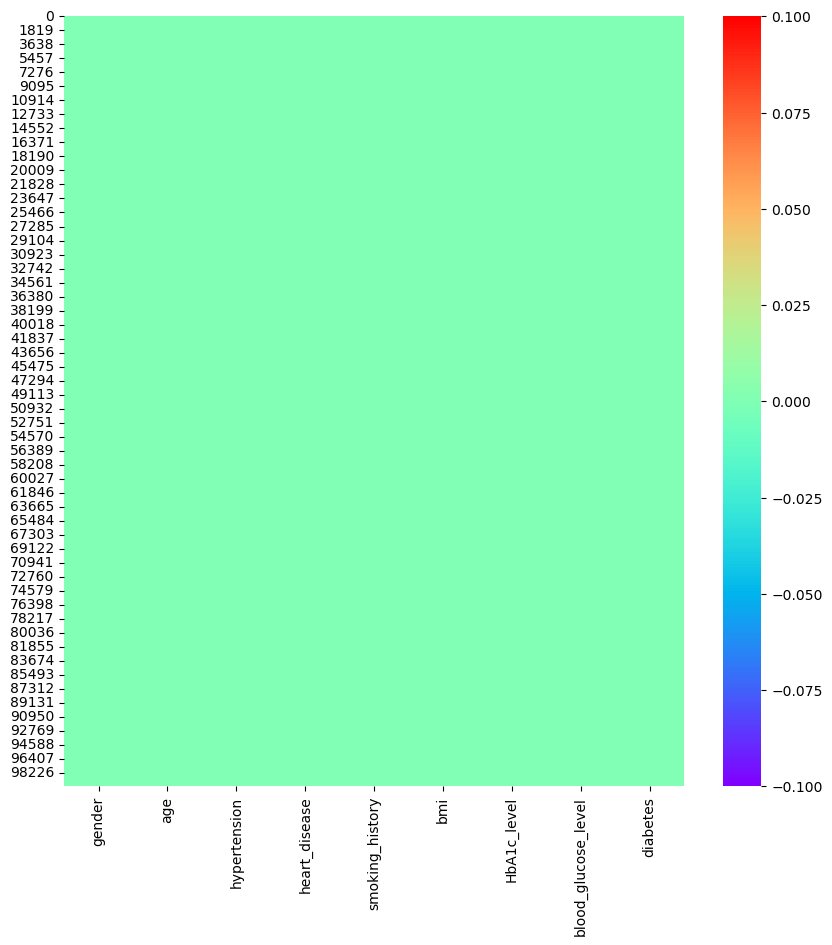

In [130]:
# check for missing data 

print(df.isnull().sum())

# Visualise the missing data 

plt.figure( figsize = (10,10))
sns.heatmap( df.isnull(), cbar = True , cmap ="rainbow");


The data has been observed to be clean without missing values . 

The chart above represents a visualisation of lack of no missing values in the data

##### Data CLeaning The Smoking History feature

Cleaning the smoking history feature as it noticed the data has even children under ten years on the data who may not have a smoking history .

This may lead to very innacurate data prediction and cleaning 

In [135]:
# combine ever , former and not current into one table .

df['smoking_history'] = df['smoking_history'].replace({'former':'past_smoker','ever':'past_smoker', 'not current':'past_smoker'})

In [136]:
df['smoking_history'].value_counts()

smoking_history
No Info        35816
never          35095
past_smoker    19803
current         9286
Name: count, dtype: int64

In [138]:
# convert the smoking history columns to lower case letters

df["smoking_history"] = df["smoking_history"].str.lower()

In [142]:
#The value count of the smoking history feature

df["smoking_history"].value_counts()

smoking_history
no info        35816
never          35095
past_smoker    19803
current         9286
Name: count, dtype: int64

In [146]:
# To remove children below 10 years as its very unlikely they have a smoking history 

underage = df[df['age'] <10]
underage['smoking_history'].value_counts()

smoking_history
no info        8392
never          1156
past_smoker     194
current          20
Name: count, dtype: int64

In [147]:
underage[underage['smoking_history'] == 'past_smoker']['diabetes'].value_counts()

diabetes
0    192
1      2
Name: count, dtype: int64

In [148]:
underage[underage['smoking_history'] == 'current']['diabetes'].value_counts()

diabetes
0    20
Name: count, dtype: int64


The data indicates that there are only 2 children under 10 years with diabetes in the smoking history list. This suggests that the information regarding smoking history may be flawed, and the two children with diabetes likely have other contributing factors. 

Additionally, it’s important to note that children under 10 typically do not have a smoking history due to their age

By dropping we are assured of a clean data machine model.

In [151]:
# Filtered the data and Dropped. 

filterdata = df[~((df['age'] <=10) & (df['smoking_history'].isin(['current','past_smoker'])))]


filterdata[filterdata["age"] <=10]["smoking_history"].unique()

array(['no info', 'never'], dtype=object)

## EDA - Exploratory Data Analysis

Univariate analysis


In [160]:
df.columns.to_list()

['gender',
 'age',
 'hypertension',
 'heart_disease',
 'smoking_history',
 'bmi',
 'HbA1c_level',
 'blood_glucose_level',
 'diabetes']

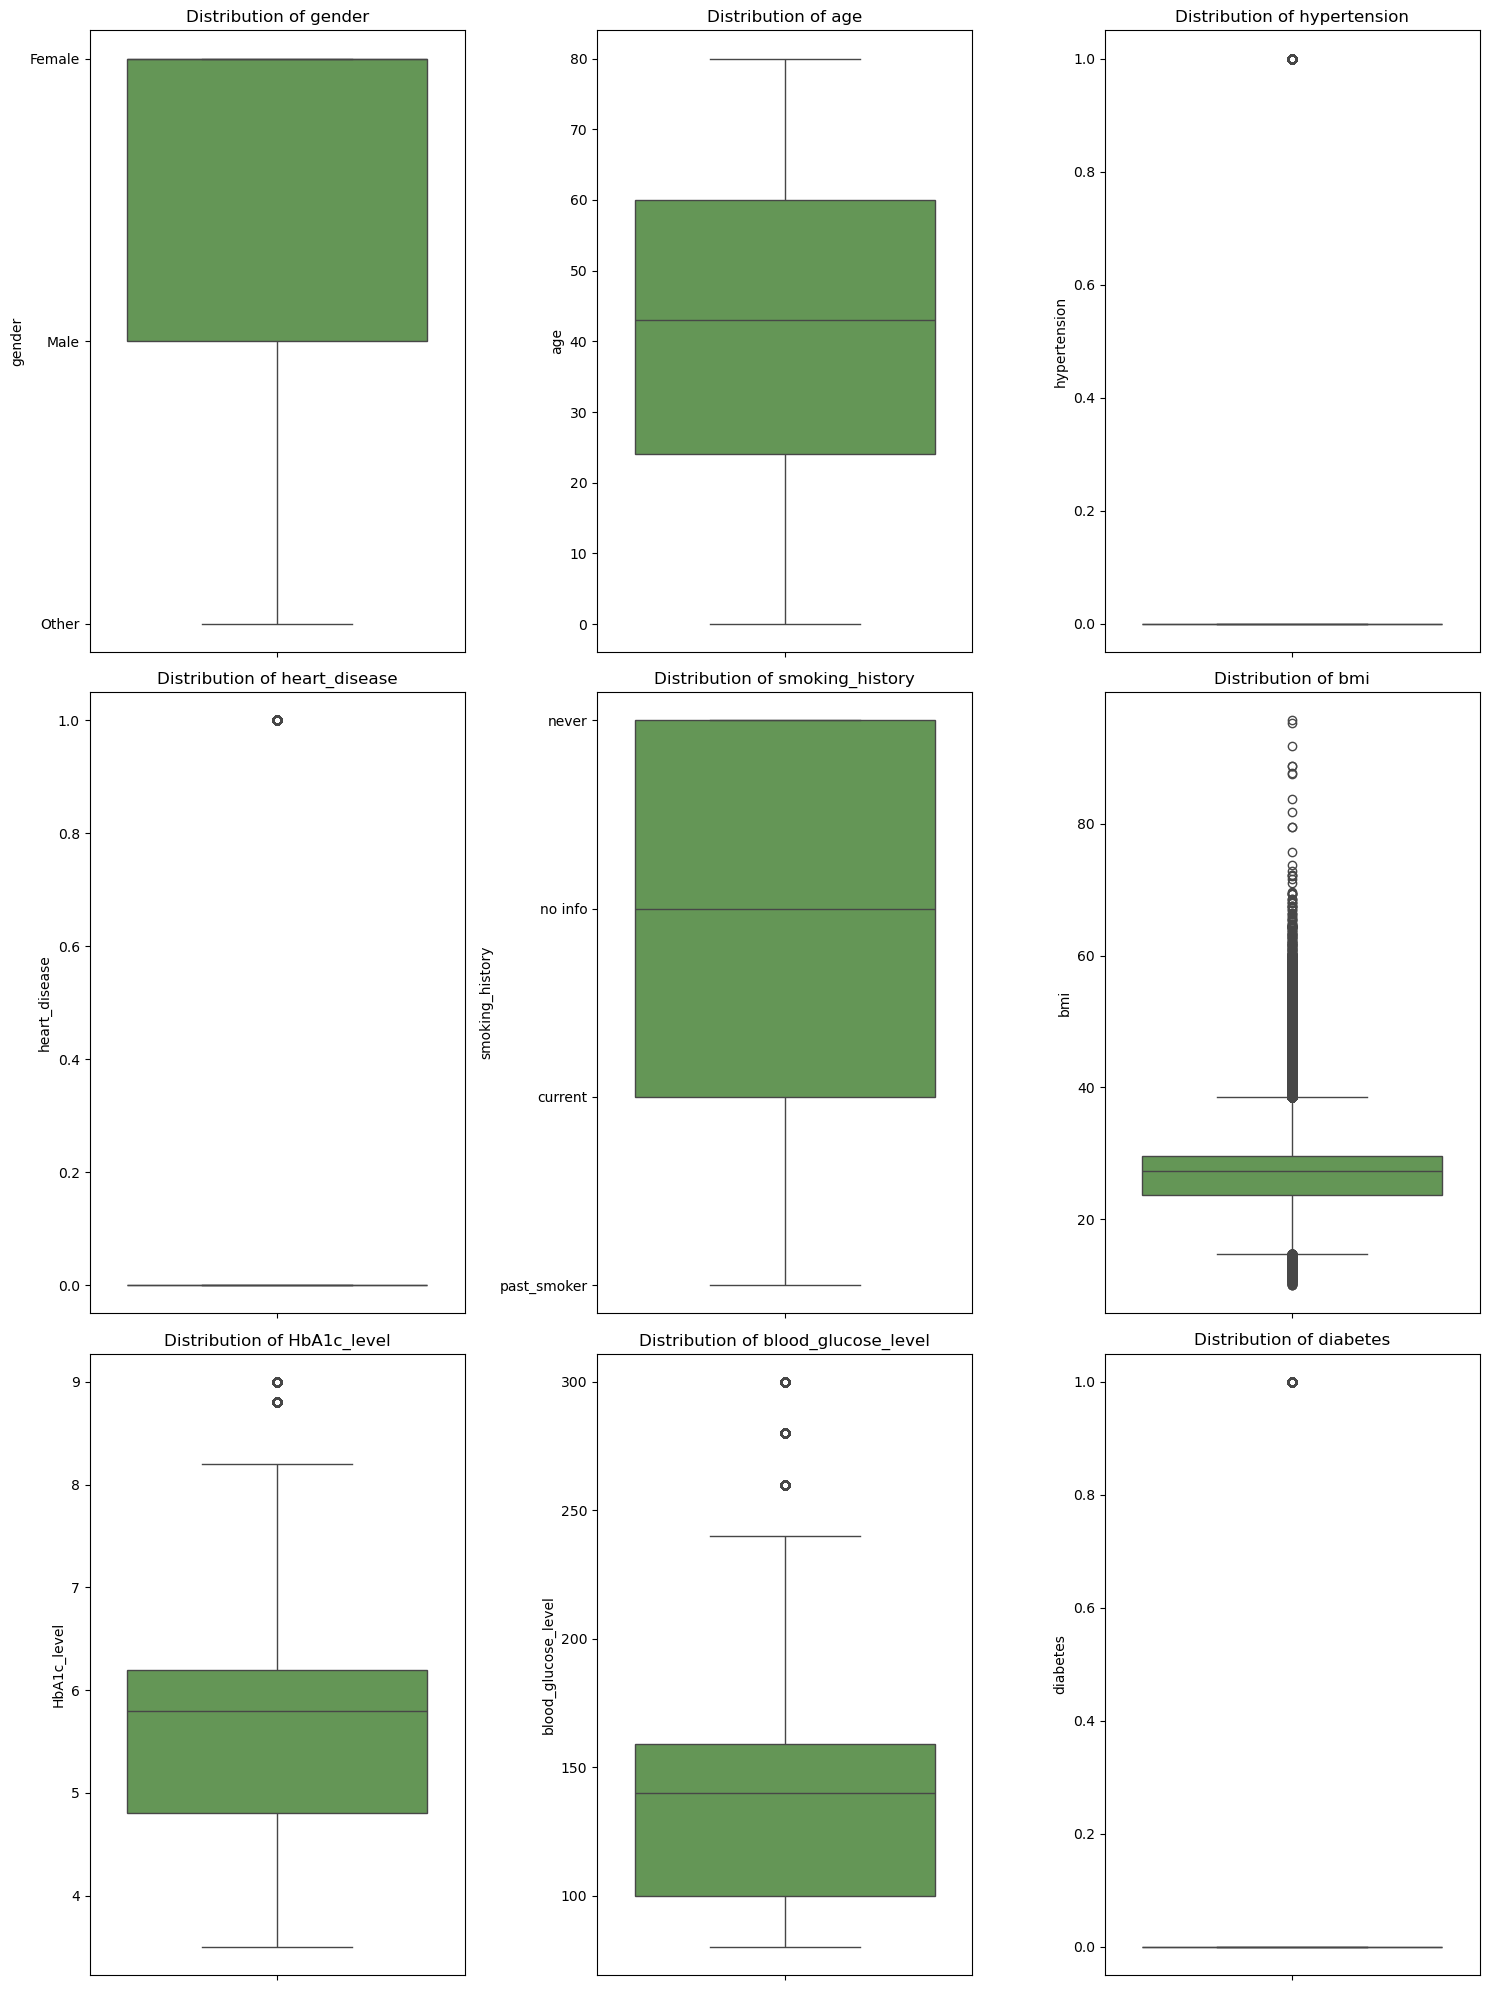

<Figure size 640x480 with 0 Axes>

In [164]:
# Checking for outliers 
# Visualization of all the 9 columns as a boxplots individually to measure median tendency and frequency

df.columns.to_list()

numerical_cols = df.columns.to_list()


_, axes = plt.subplots(nrows =3, ncols =3, figsize = (15, 20))

position = axes.flatten()

for index, column_name in enumerate(numerical_cols):
    sns.boxplot(df[column_name] , palette= "gist_earth" , ax=position[index])
    position[index].set_title(f"Distribution of {column_name}")

plt.tight_layout()
plt.show()
plt.savefig(r"C:\Users\Ndumbi Kimani\OneDrive\Desktop\Chart.png")


Gender Distribution: Most of the individuals are female, with fewer males represented, and very few (if any) categorized as "Other."

Age Distribution: The median age is around 40-50 years, with ages ranging from 0 to about 80. The data has a fairly balanced spread with no significant outliers.

Hypertension: Almost all individuals have a value of 0 for hypertension, indicating most do not have the condition. There’s a single outlier indicating hypertension in one case.

Heart Disease: Similarly, the majority of individuals do not have heart disease, with only one outlier indicating the presence of heart disease.

Smoking History: The distribution shows that a large portion of the individuals fall under the "no info" or "never smoked" category, with some instances of past smokers. There seem to be no current smokers recorded.

BMI Distribution: The median BMI is around 25-30, within the overweight category. However, there are numerous high outliers above 40, suggesting several individuals may be classified as obese or severely obese.

Key Takeaways:
Most individuals are female, middle-aged, and do not have heart disease or hypertension, but some show elevated risks with high BMI and possible smoking history.
There are a few notable outliers for hypertension, heart disease, and BMI that could be areas of concern.
The combination of high BMI and the presence of smoking history and heart disease suggests that some individuals in the dataset may be at risk for cardiovascular issues.

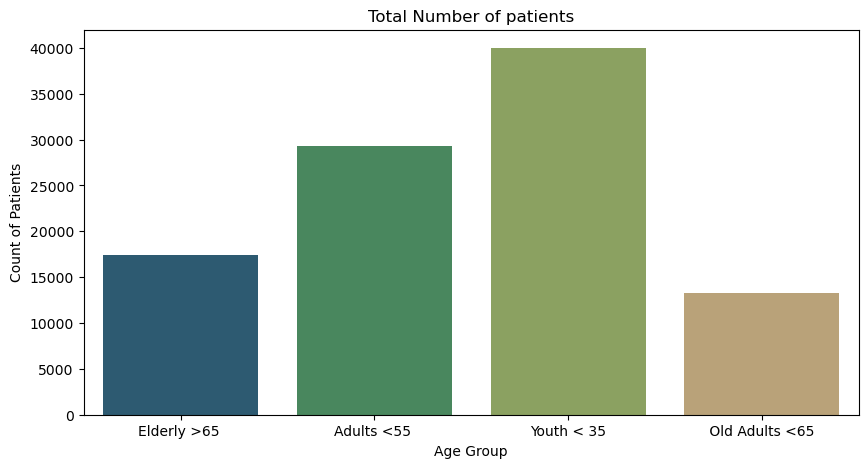

In [167]:
## Count Data visualisation # Age groups and brackets .

def age_bracket (age):
    if age <= 35:
        return 'Youth < 35'
    elif age <= 55 :
        return 'Adults <55 '
    elif age <= 65 :
        return ' Old Adults <65 '
    else:
        age >= 65 
        return 'Elderly >65 '

df['age_bracket'] = df['age'].apply(age_bracket)

plt.figure(figsize = (10,5))
sns.countplot( x="age_bracket", data= df, palette= "gist_earth" )
plt.xlabel("Age Group")
plt.ylabel("Count of Patients")
plt.title("Total Number of patients")

plt.savefig(r"C:\Users\Ndumbi Kimani\OneDrive\Desktop\Chart 1.png");

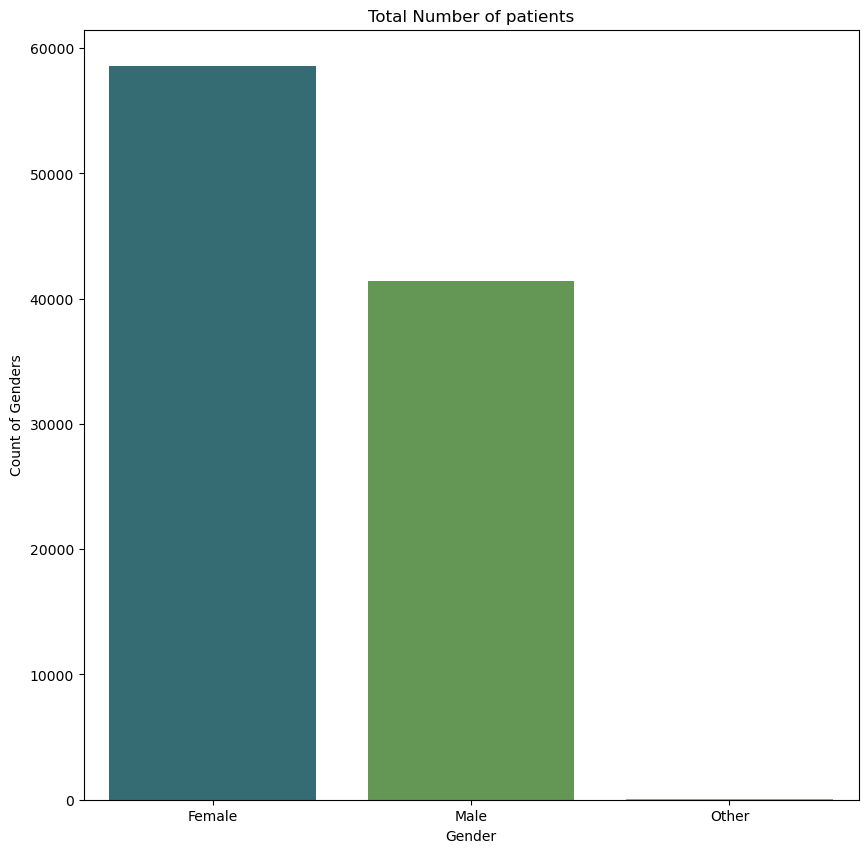

In [168]:
## Count Data visualisation # Type of Genders.

plt.figure(figsize = (10,10))
sns.countplot( x= 'gender', data = df, palette= "gist_earth")
plt.xlabel("Gender")
plt.ylabel("Count of Genders")
plt.title("Total Number of patients");



Its noted that many patients recorded that are affected by diabetes are female , then followed by men who follow second 

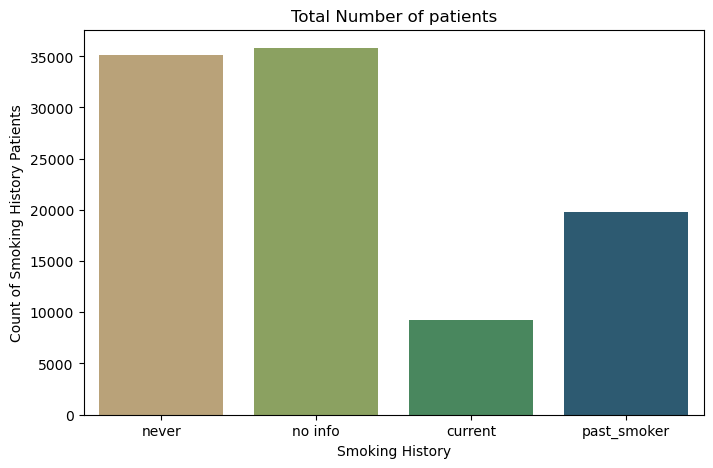

In [172]:
## Count Data visualisation # Smoking History.
plt.figure(figsize = (8,5))
sns.countplot( x= 'smoking_history', data = df, palette= "gist_earth_r")
plt.xlabel("Smoking History")
plt.ylabel("Count of Smoking History Patients")
plt.title("Total Number of patients");

There no correlation between smoking history and diabetes. From the visualisation we can rule out smoking as a factor for diabetes 

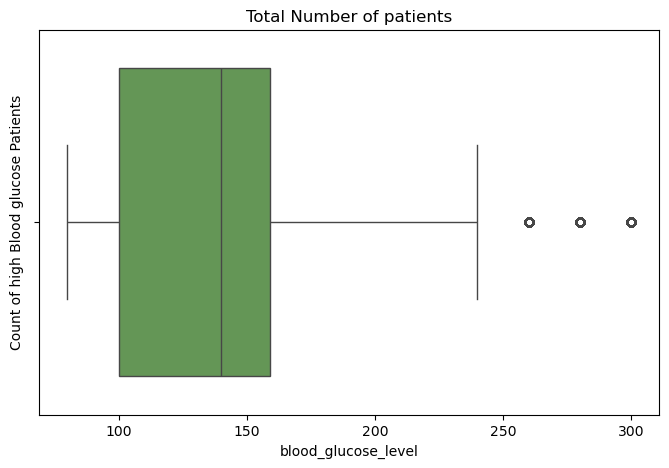

In [174]:
## Count Data visualisation # Blood glucose level

plt.figure(figsize = (8,5))
sns.boxplot( x= 'blood_glucose_level', data = df, palette= "gist_earth")
plt.xlabel("blood_glucose_level")
plt.ylabel("Count of high Blood glucose Patients")
plt.title("Total Number of patients");

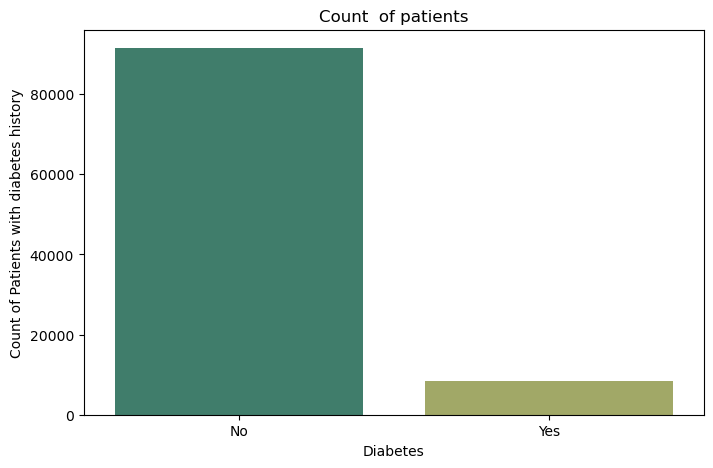

In [176]:
## Count Data visualisation # Diabetes patients .
def diabetes(diabetes):
    if diabetes == 1:
        return 'Yes'
    else:
        return 'No'
df['diabetes_code'] = df['diabetes'].apply(diabetes)
plt.figure(figsize = (8,5))
sns.countplot( x= 'diabetes_code', data = df, palette= "gist_earth")
plt.xlabel("Diabetes")
plt.ylabel("Count of Patients with diabetes history")
plt.title("Count  of patients");

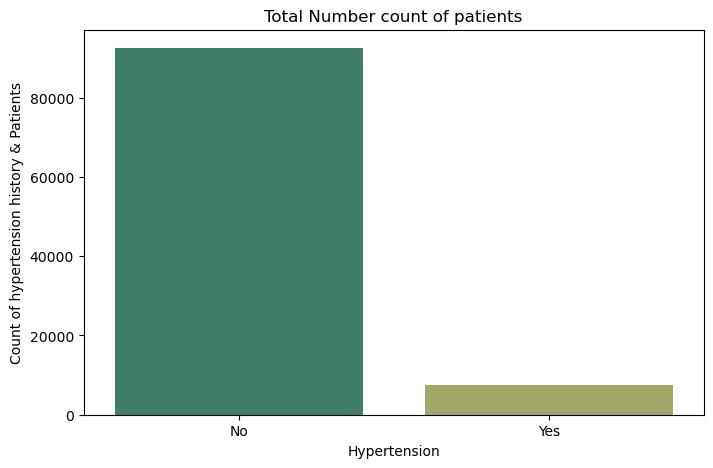

In [177]:
## Count Data visualisation # Hypertension  patients .
def hypertension(hypertension):
    if hypertension == 1:
        return 'Yes'
    else:
        return 'No'
df['hypertension_code'] = df['hypertension'].apply(hypertension)
plt.figure(figsize = (8,5))
sns.countplot( x= 'hypertension_code', data = df, palette= "gist_earth")
plt.xlabel("Hypertension")
plt.ylabel("Count of hypertension history & Patients")
plt.title("Total Number count of patients");

In [178]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes', 'age_bracket',
       'diabetes_code', 'hypertension_code'],
      dtype='object')

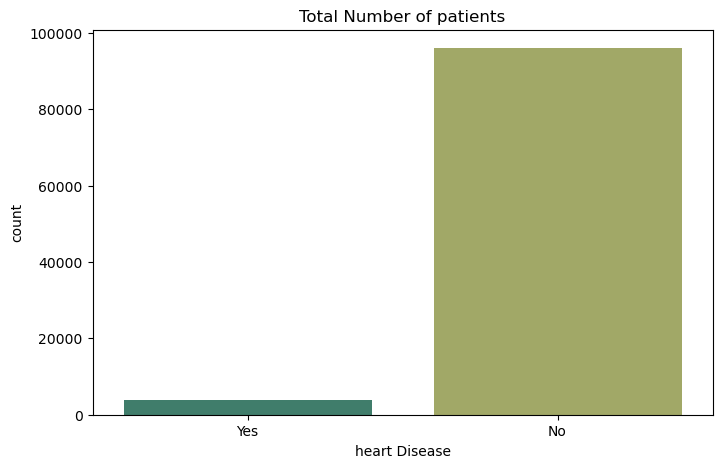

In [179]:
## Count Data visualisation # Heart disease patients .
def heart_disease(heart_disease):
    if heart_disease == 1:
        return 'Yes'
    else:
        return 'No'
df['heart_disease_code'] = df['heart_disease'].apply(heart_disease)
plt.figure(figsize = (8,5))
sns.countplot( x= 'heart_disease_code', data = df, palette= "gist_earth")
plt.xlabel("heart Disease")
plt.title("Total Number of patients");

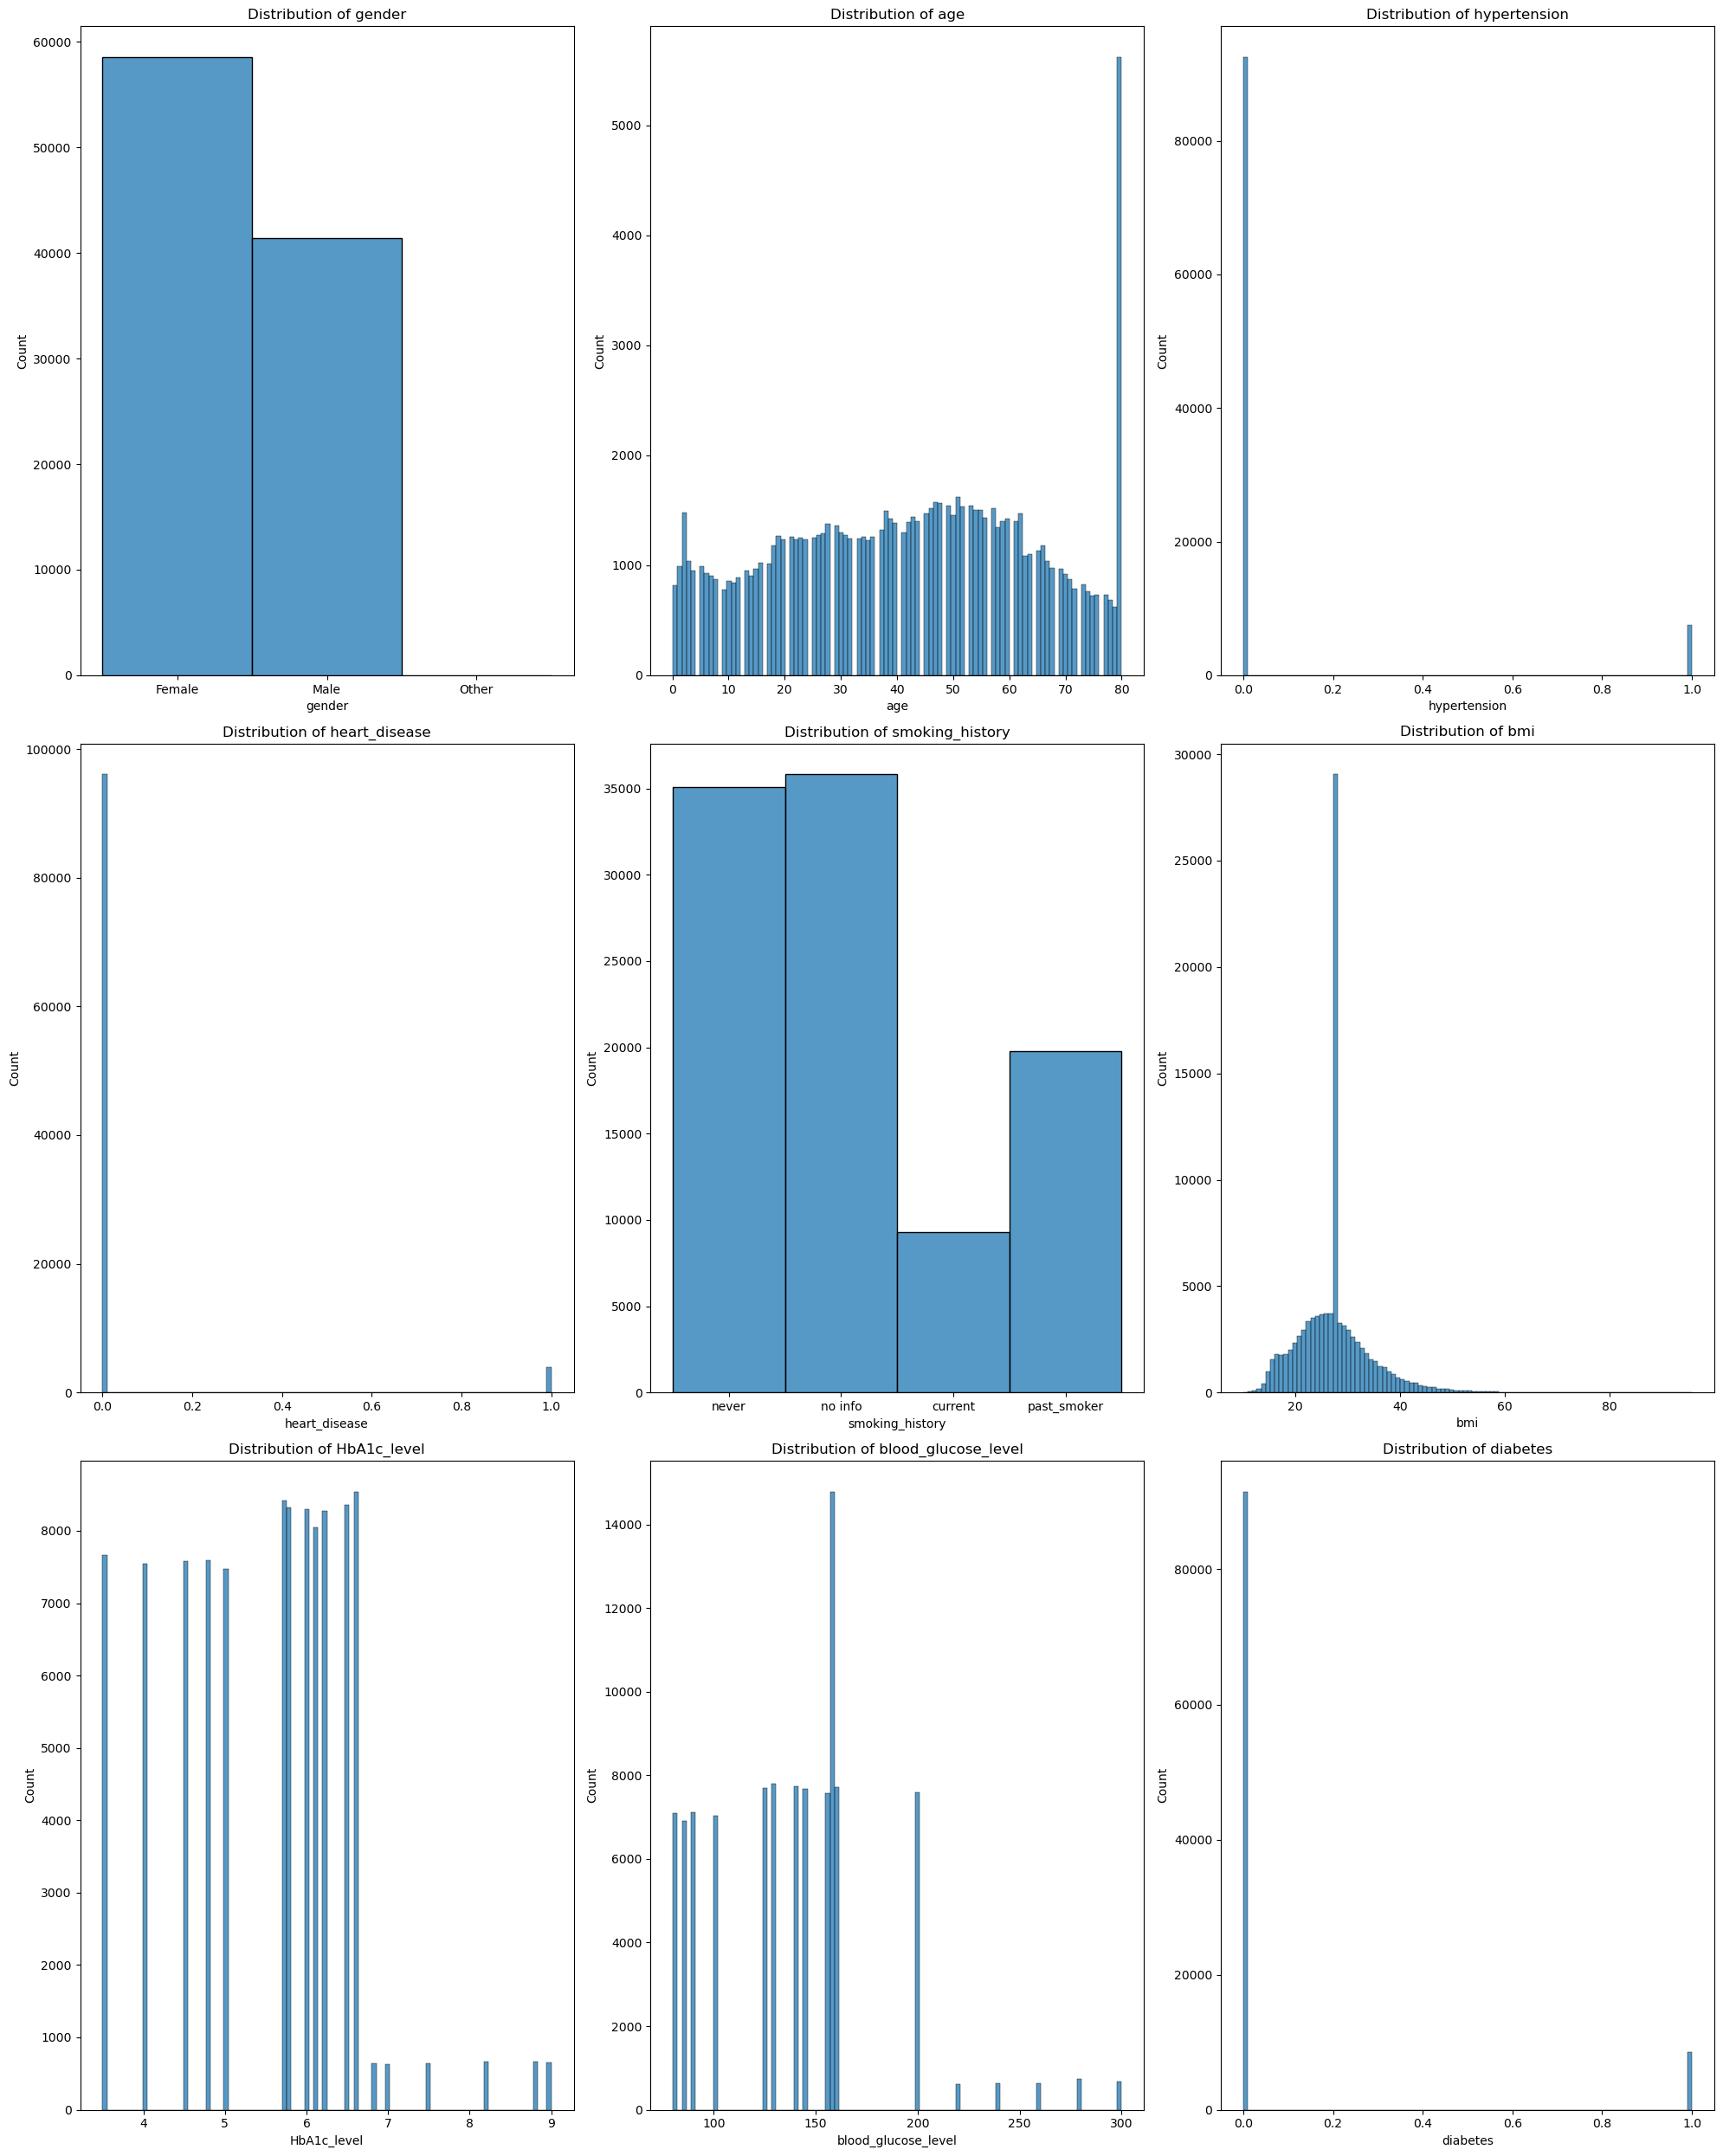

In [180]:
## checking the distribution pattern of our datset 

_, axes = plt.subplots(nrows =3, ncols =3, figsize = (20, 25))

position = axes.flatten()

for index, column_name in enumerate(numerical_cols):
    sns.histplot(df[column_name] , bins=100, palette= "gist_earth" , ax=position[index])
    position[index].set_title(f"Distribution of {column_name}")

plt.tight_layout()
plt.show()

The Visualisation shows us the data is a skkewed distribution to the right.

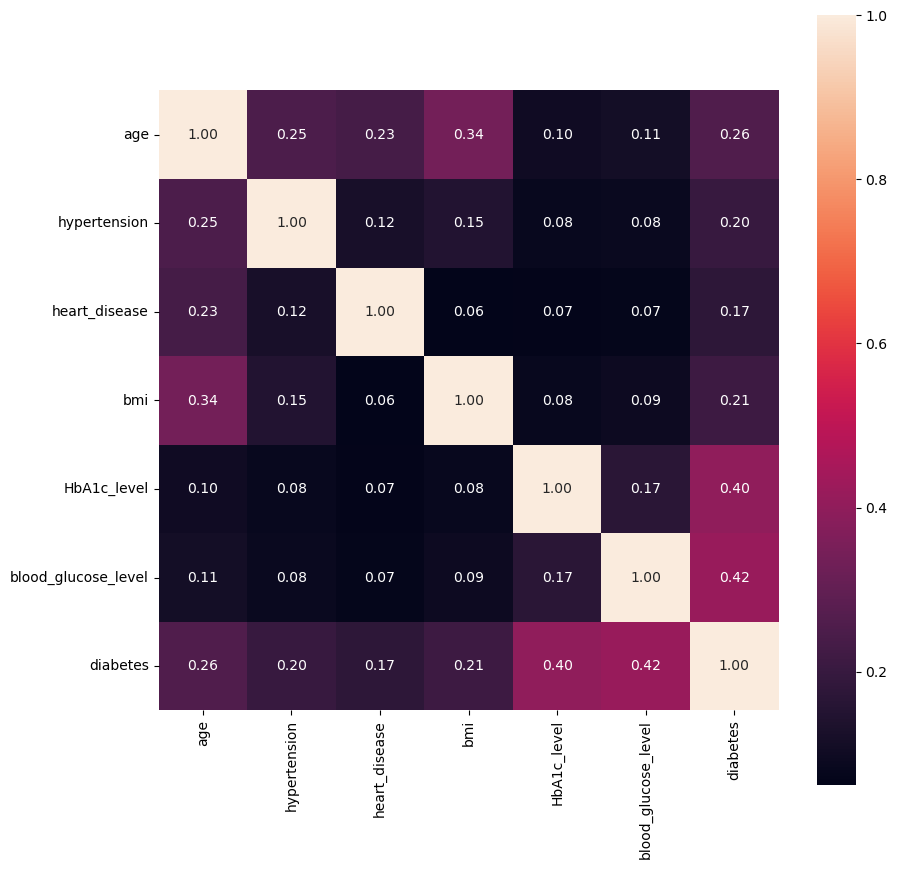

In [182]:
# coorelation of variables in the dataset


numerical_df = df.select_dtypes(exclude = "object")

corr = numerical_df.corr

plt.figure(figsize = (10,10))

hm = sns.heatmap(corr(), cbar=True , annot=True, square =True, fmt='.2f', annot_kws={"size":10});

## Bivariate Analysis

In [186]:
## Categorical Data EDA

categorical_df = df.select_dtypes(include = "object")
categorical_df

,gender,smoking_history,age_bracket,diabetes_code,hypertension_code,heart_disease_code
0,Female,never,Elderly >65,No,No,Yes
1,Female,no info,Adults <55,No,No,No
2,Male,never,Youth < 35,No,No,No
3,Female,current,Adults <55,No,No,No
4,Male,current,Elderly >65,No,Yes,Yes
...,...,...,...,...,...,...
99995,Female,no info,Elderly >65,No,No,No
99996,Female,no info,Youth < 35,No,No,No
99997,Male,past_smoker,Elderly >65,No,No,No
99998,Female,never,Youth < 35,No,No,No


In [187]:
numerical_df

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
0,80.0,0,1,25.19,6.6,140,0
1,54.0,0,0,27.32,6.6,80,0
2,28.0,0,0,27.32,5.7,158,0
3,36.0,0,0,23.45,5.0,155,0
4,76.0,1,1,20.14,4.8,155,0
...,...,...,...,...,...,...,...
99995,80.0,0,0,27.32,6.2,90,0
99996,2.0,0,0,17.37,6.5,100,0
99997,66.0,0,0,27.83,5.7,155,0
99998,24.0,0,0,35.42,4.0,100,0


In [189]:
cat_columns = categorical_df.columns.to_list()

for features in cat_columns:

    print(f" {features} ------  {categorical_df[features].nunique()}")
    print("\n")

 gender ------  3


 smoking_history ------  4


 age_bracket ------  4


 diabetes_code ------  2


 hypertension_code ------  2


 heart_disease_code ------  2




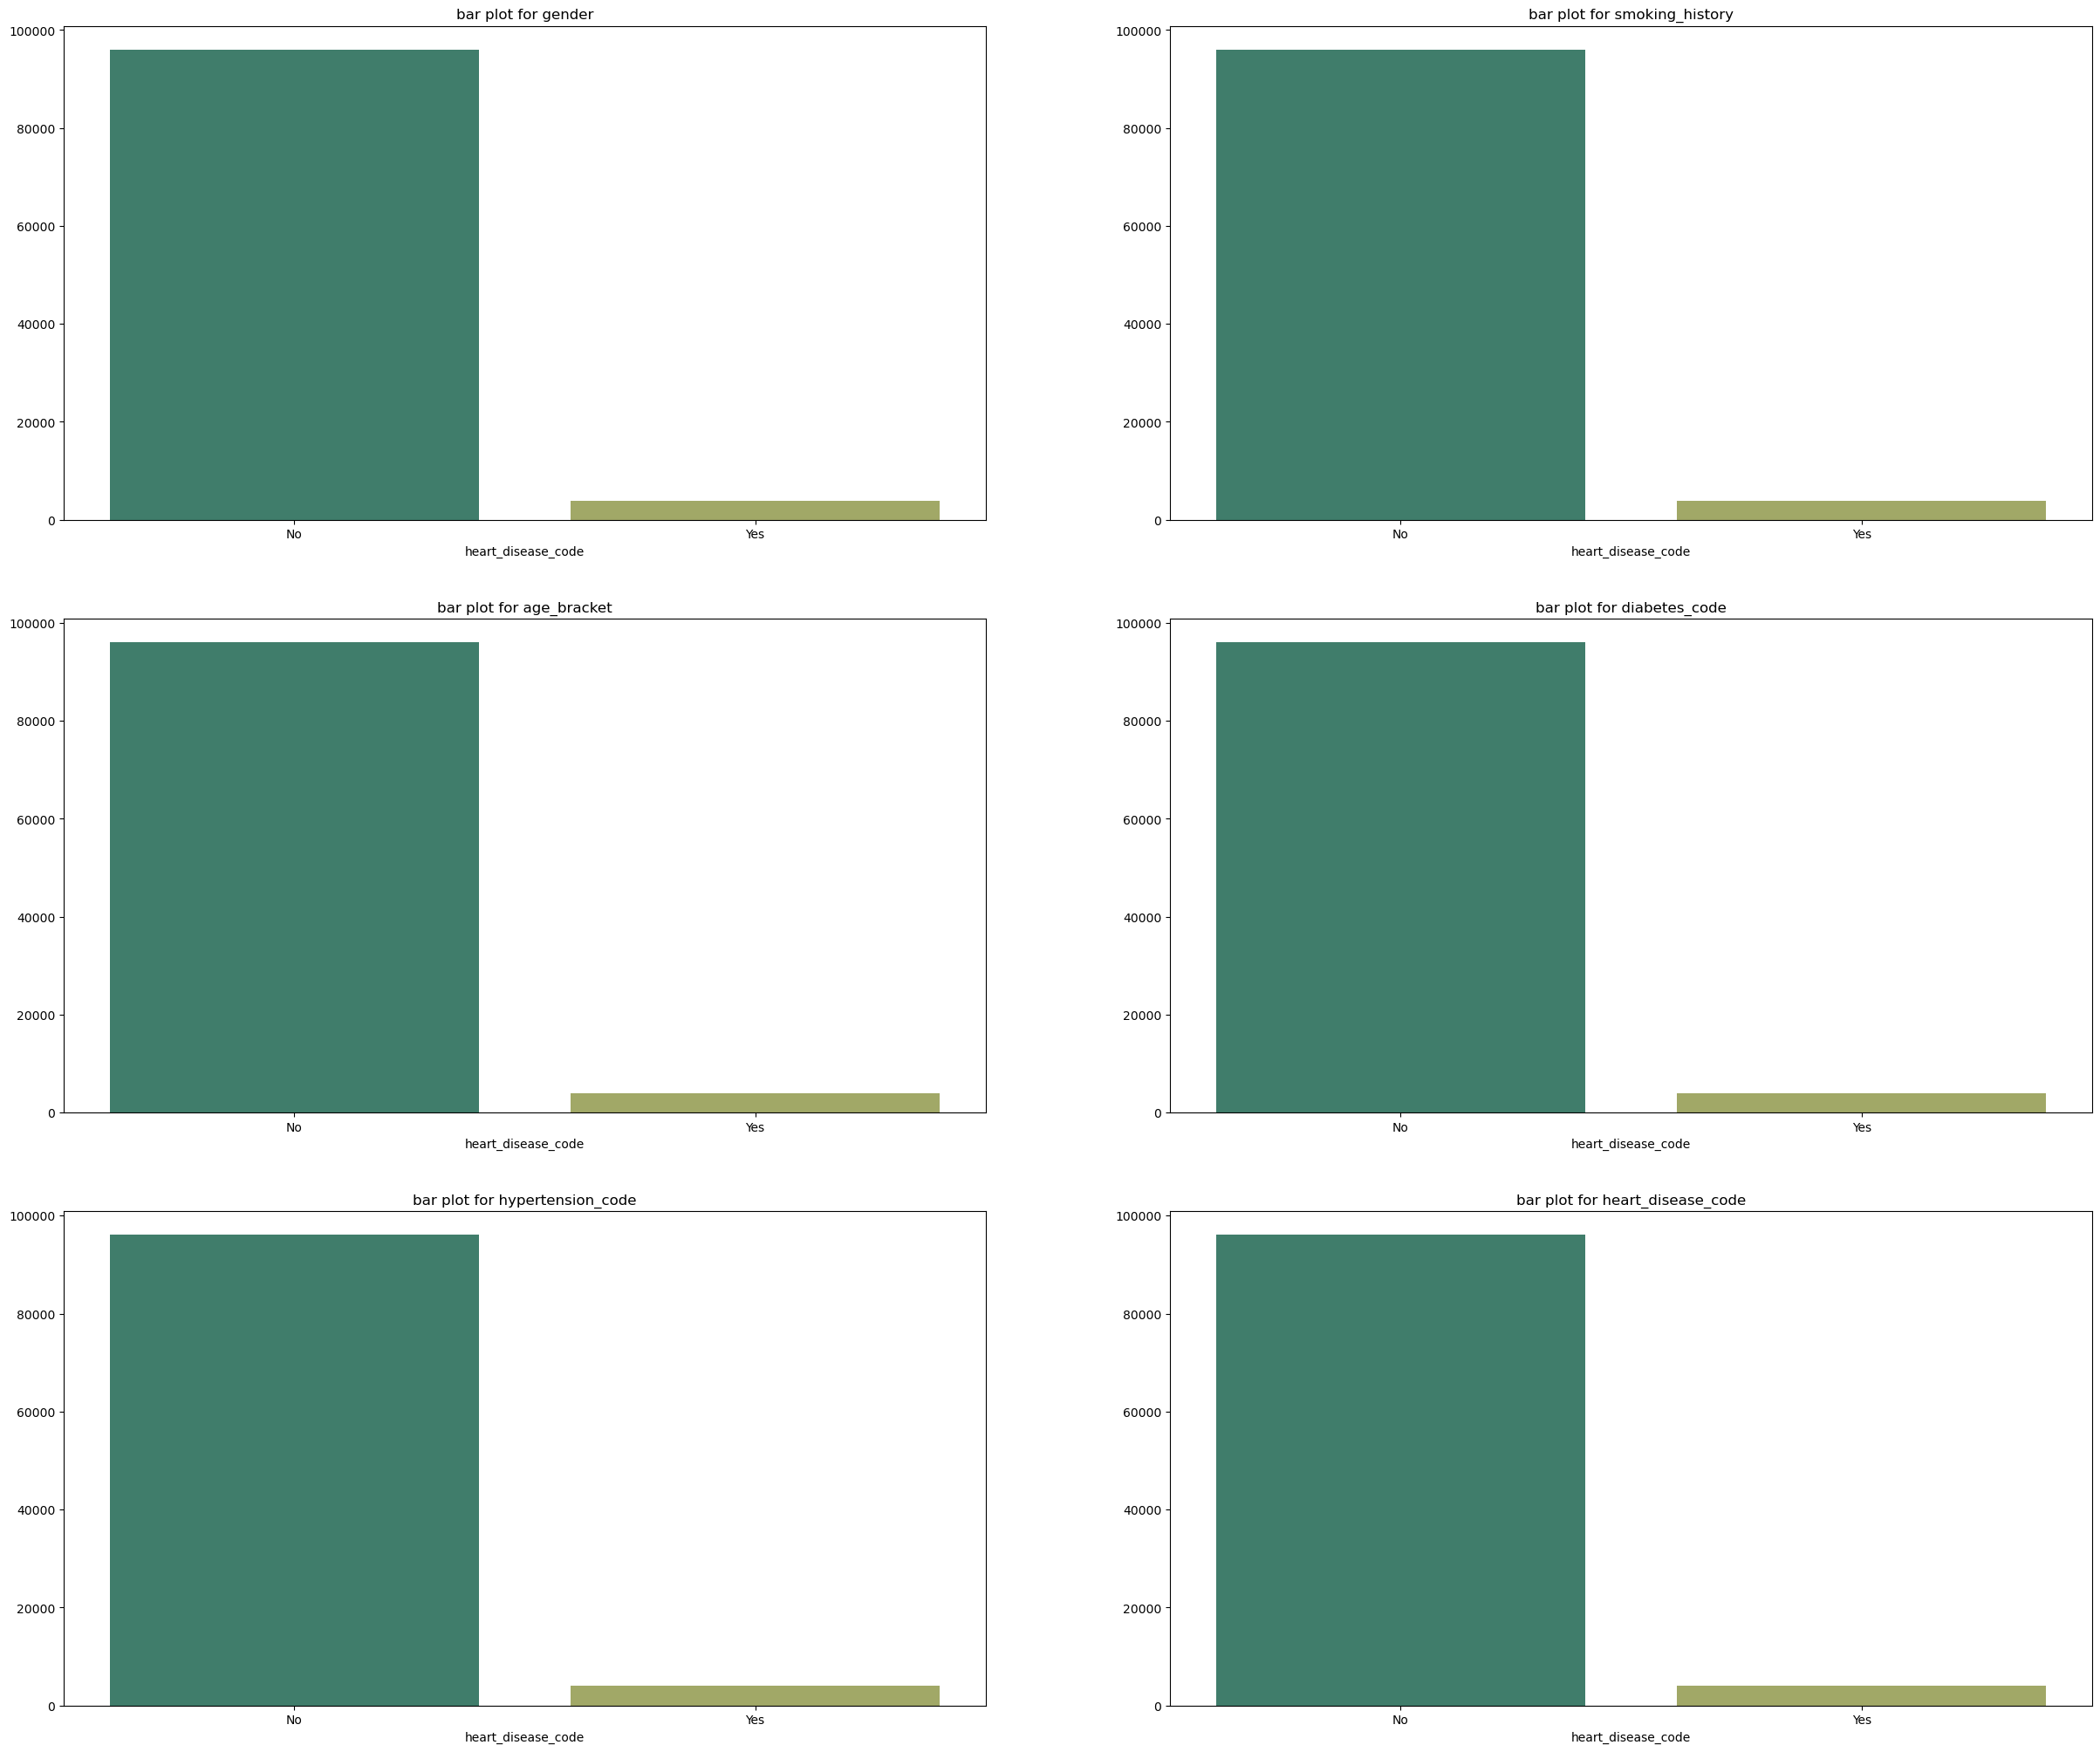

In [191]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize = (30,25))

position = axes.flatten()

for index, feature in enumerate(cat_columns):
    sns.barplot(x = categorical_df[features].value_counts().index, y =categorical_df[features].value_counts().values, 
               ax = position[index], palette= "gist_earth" )
    position[index].set_title(f"bar plot for {feature}")
    
plt.show()

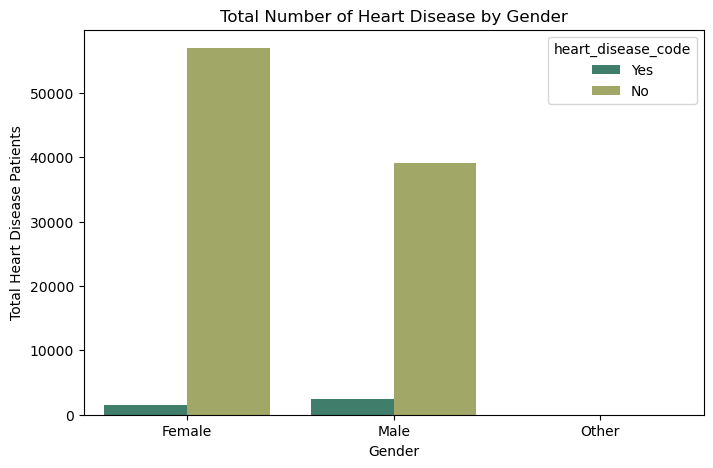

In [194]:
# investigating a patients Gender and heart disease


plt.figure(figsize = (8,5))
sns.countplot( x= 'gender', data = df, hue= 'heart_disease_code', palette= "gist_earth")
plt.xlabel("Gender")
plt.ylabel("Total Heart Disease Patients")
plt.title("Total Number of Heart Disease by Gender");

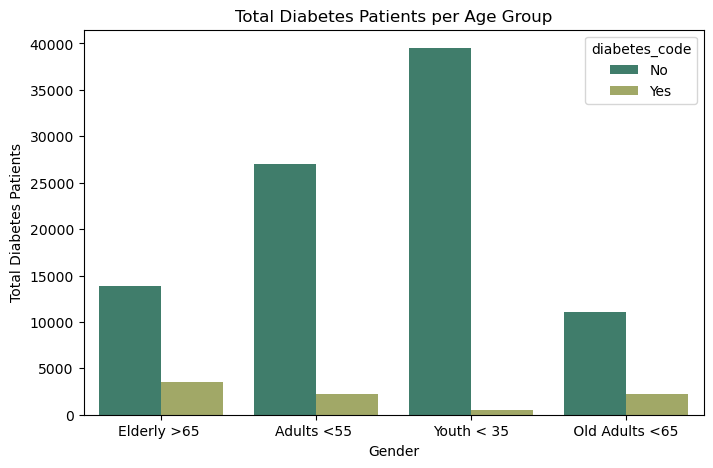

In [195]:
# investigating diabetes patients by age group


plt.figure(figsize = (8,5))
sns.countplot( x= 'age_bracket', data = df, hue= 'diabetes_code',palette= "gist_earth" )
plt.xlabel("Gender")
plt.ylabel("Total Diabetes Patients")
plt.title("Total Diabetes Patients per Age Group");

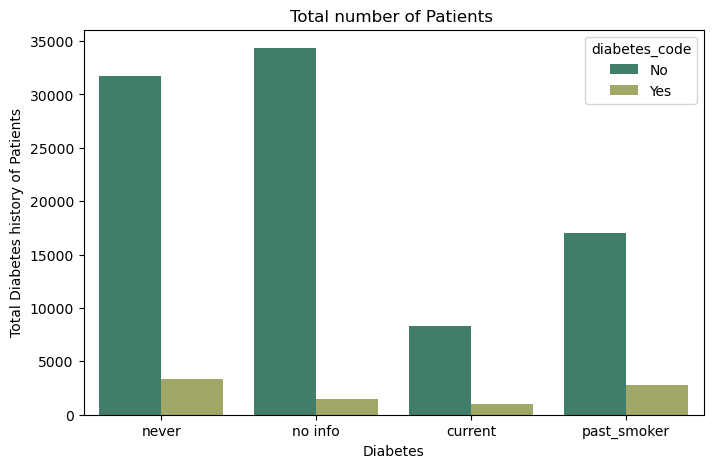

In [196]:
# investigating a patients smoking history  and diabetes


plt.figure(figsize = (8,5))
sns.countplot( x= 'smoking_history', data = df, hue= 'diabetes_code',palette= "gist_earth")
plt.xlabel("Diabetes")
plt.ylabel("Total Diabetes history of Patients")
plt.title("Total number of Patients ");

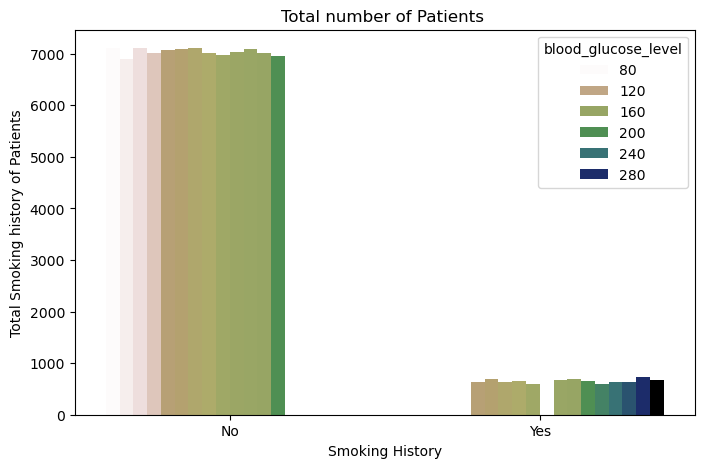

In [197]:
# investigating a patients blood glucose level and diabetes


plt.figure(figsize = (8,5))
sns.countplot( x= 'diabetes_code', data = df, hue= 'blood_glucose_level', palette= "gist_earth_r")
plt.xlabel("Smoking History")
plt.ylabel("Total Smoking history of Patients")
plt.title("Total number of Patients ");

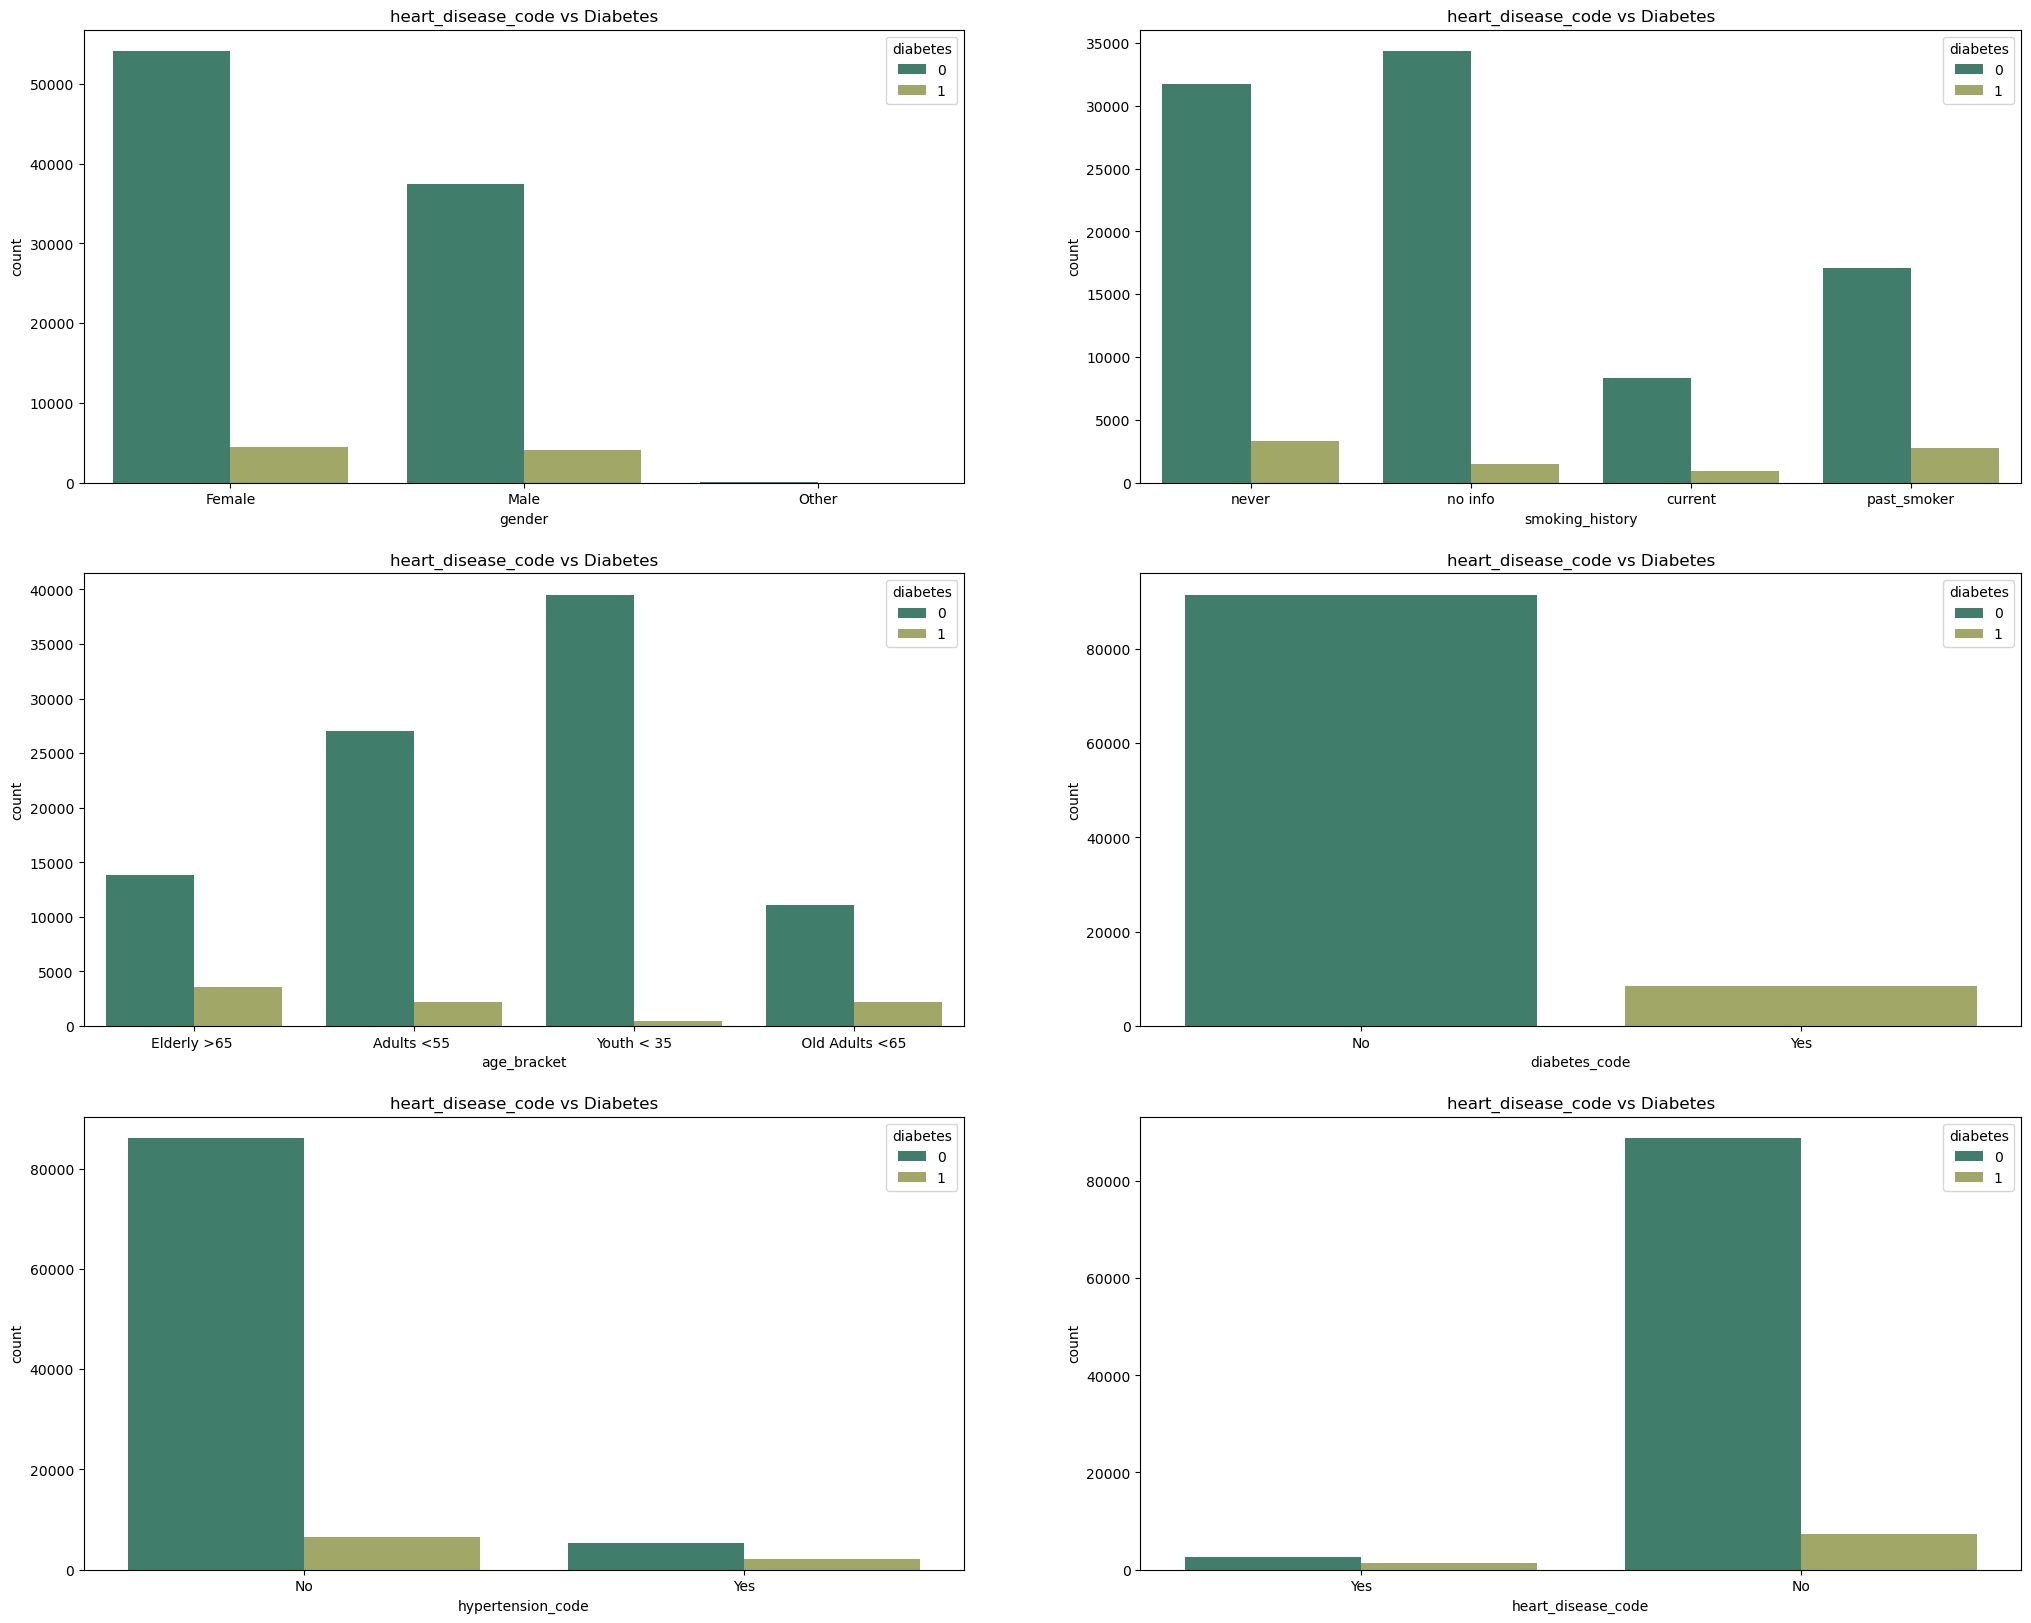

In [199]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize = (25,20))

position = axes.flatten()

for index, features in enumerate(cat_columns):
    sns.countplot(data = categorical_df, x  =features, hue = df["diabetes"], ax = position[index], palette= "gist_earth")
    position[index].set_title(f"{feature} vs Diabetes")
    


## Multivariate Analysis

In [204]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,age_bracket,diabetes_code,hypertension_code,heart_disease_code
0,Female,80.0,0,1,never,25.19,6.6,140,0,Elderly >65,No,No,Yes
1,Female,54.0,0,0,no info,27.32,6.6,80,0,Adults <55,No,No,No
2,Male,28.0,0,0,never,27.32,5.7,158,0,Youth < 35,No,No,No
3,Female,36.0,0,0,current,23.45,5.0,155,0,Adults <55,No,No,No
4,Male,76.0,1,1,current,20.14,4.8,155,0,Elderly >65,No,Yes,Yes


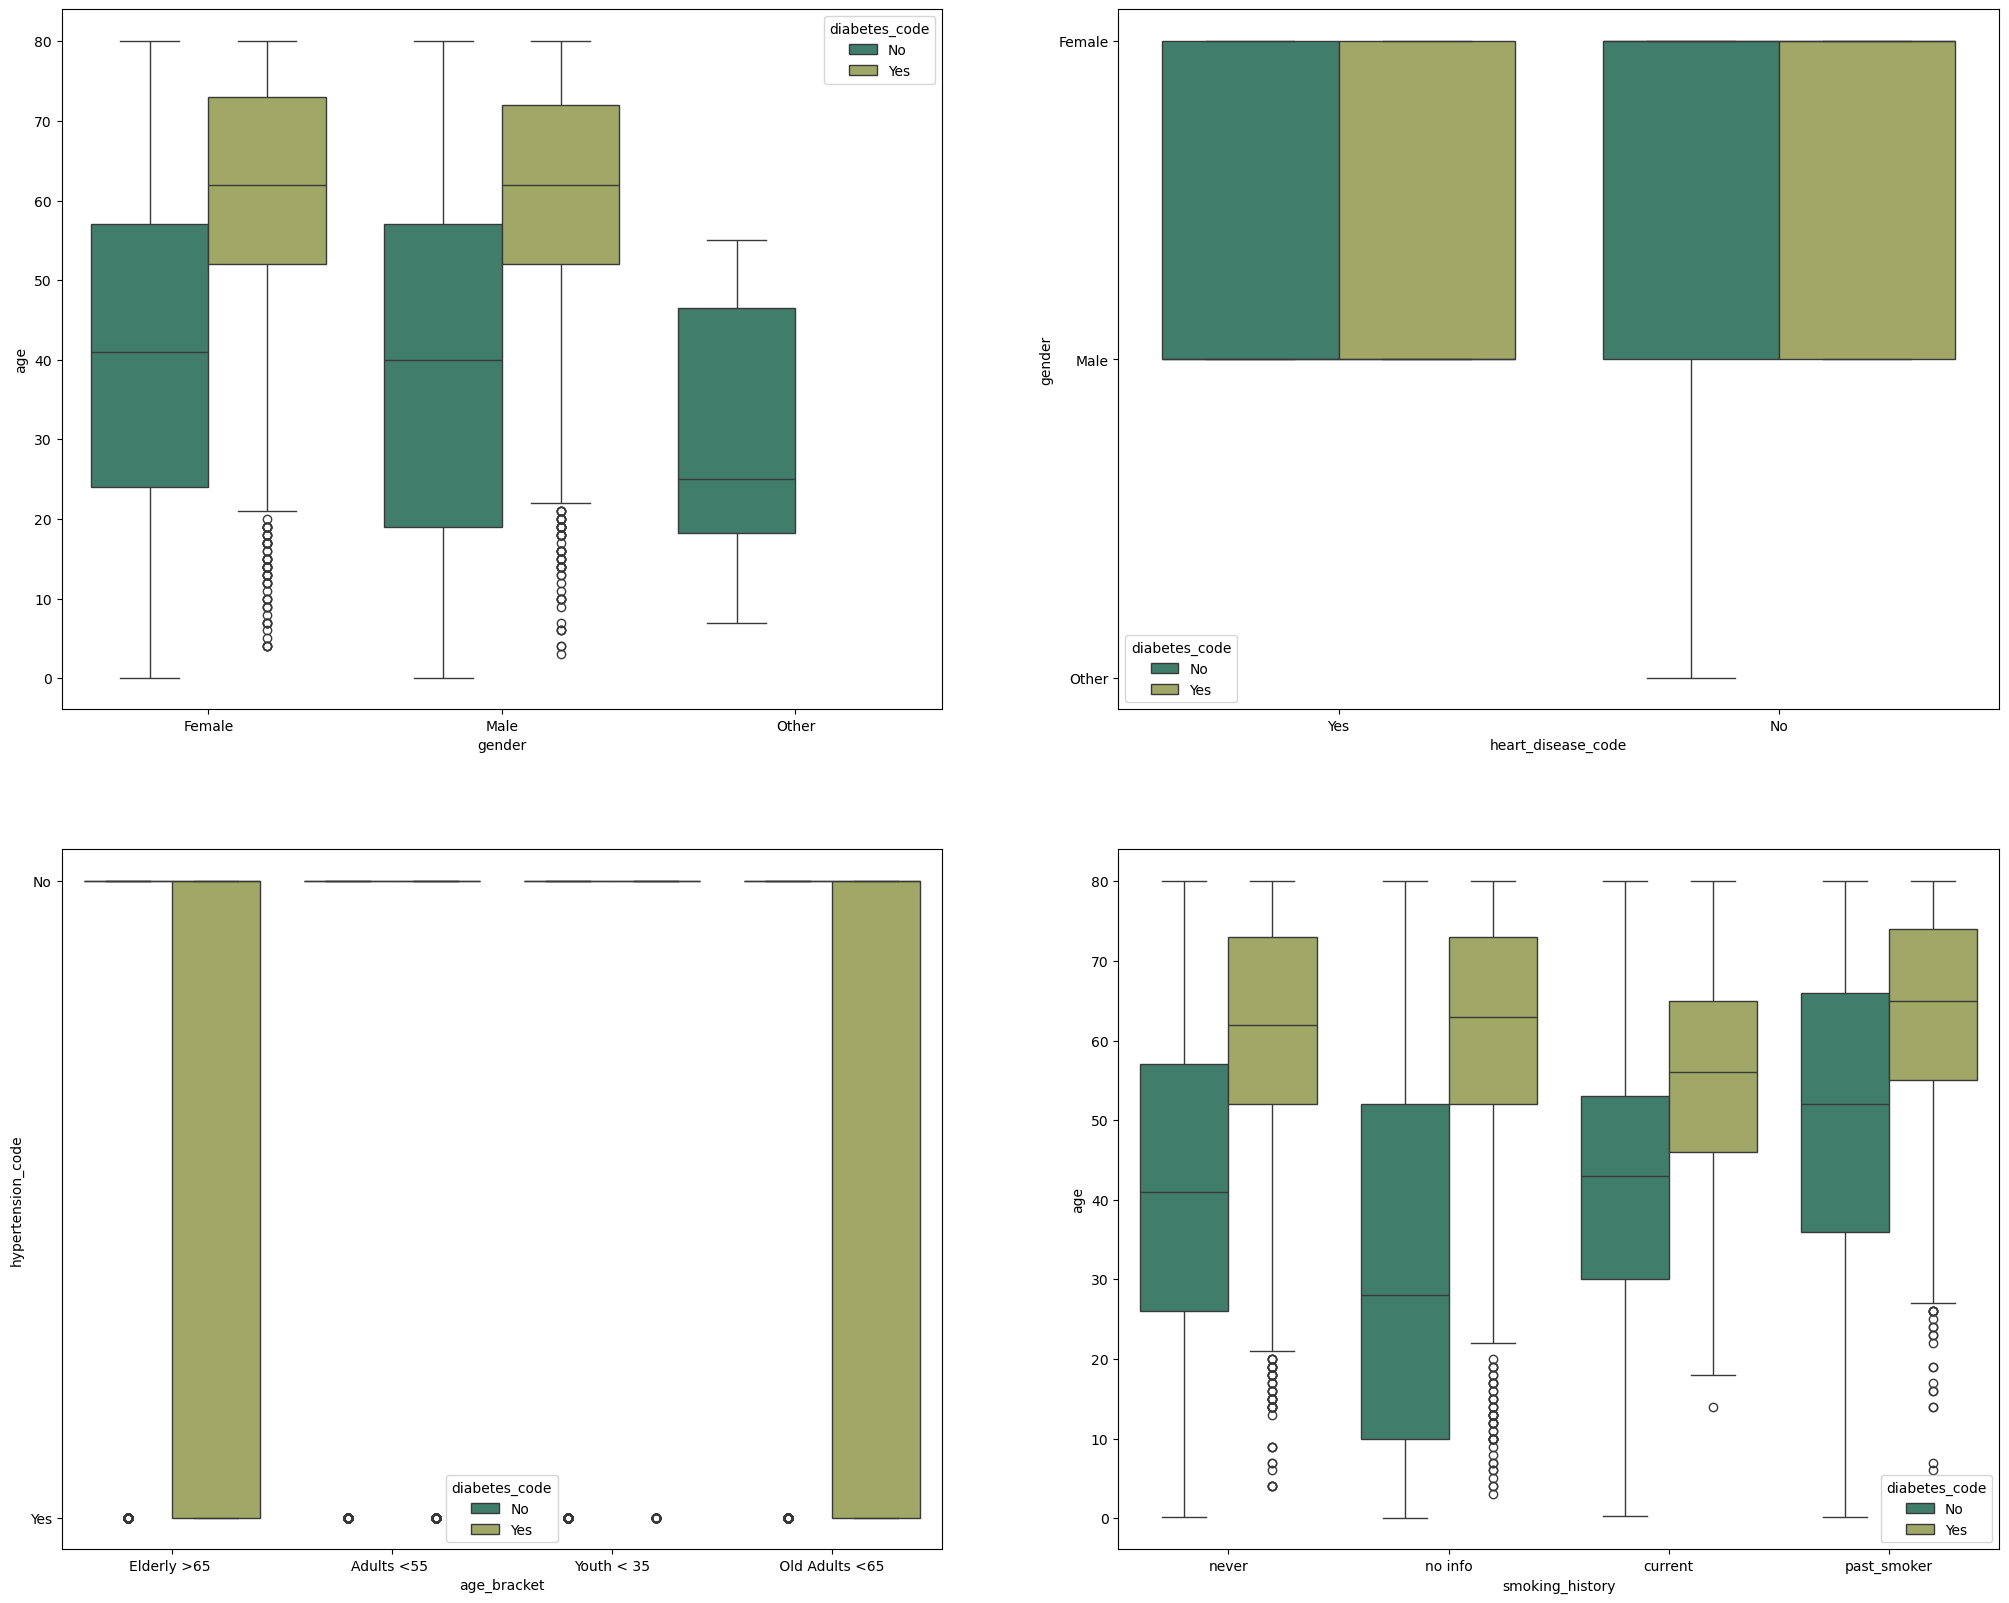

In [207]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize = (25,20))

sns.boxplot(x="gender", y="age", hue="diabetes_code", data=df, ax= axes[0,0], palette= "gist_earth")
sns.boxplot(x="heart_disease_code", y="gender", hue="diabetes_code", data=df, ax= axes[0,1], palette= "gist_earth")
sns.boxplot(x="age_bracket", y="hypertension_code", hue="diabetes_code", data=df, ax= axes[1,0], palette= "gist_earth")
sns.boxplot(x="smoking_history", y="age", hue="diabetes_code", data=df, ax= axes[1,1], palette= "gist_earth")

plt.show()

### Feature Engineering/ Data Pre -processing

In [210]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,age_bracket,diabetes_code,hypertension_code,heart_disease_code
0,Female,80.0,0,1,never,25.19,6.6,140,0,Elderly >65,No,No,Yes
1,Female,54.0,0,0,no info,27.32,6.6,80,0,Adults <55,No,No,No
2,Male,28.0,0,0,never,27.32,5.7,158,0,Youth < 35,No,No,No
3,Female,36.0,0,0,current,23.45,5.0,155,0,Adults <55,No,No,No
4,Male,76.0,1,1,current,20.14,4.8,155,0,Elderly >65,No,Yes,Yes


In [211]:
# new data frame for pre-processing for the model training
# Organising features 
dfc = df[['gender',
         'age',
         'hypertension',
         'heart_disease',
         'smoking_history',
         'bmi',
         'HbA1c_level',
         'blood_glucose_level',
          'diabetes'
         ]]

In [212]:
dfc.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,no info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [213]:
labels = dfc['diabetes']
features = dfc.drop(['diabetes'], axis=1)

In [214]:
len(labels) == len(features)

True

### Encoding categorical variables
#### Using Label Encoding

In [216]:
all_categorical_column = features.select_dtypes(include=['object'])

In [217]:
all_categorical_column.head()

,gender,smoking_history
0,Female,never
1,Female,no info
2,Male,never
3,Female,current
4,Male,current


In [218]:
# Encoding categorical variables
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

In [219]:
for categorical_columns in all_categorical_column:
    print(categorical_columns)

gender
smoking_history


In [220]:
for categorical_column in all_categorical_column:
    features[categorical_column] = encoder.fit_transform(features[categorical_column])

In [223]:
features.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,0,80.0,0,1,1,25.19,6.6,140
1,0,54.0,0,0,2,27.32,6.6,80
2,1,28.0,0,0,1,27.32,5.7,158
3,0,36.0,0,0,0,23.45,5.0,155
4,1,76.0,1,1,0,20.14,4.8,155


In [226]:
labels.head()

0    0
1    0
2    0
3    0
4    0
Name: diabetes, dtype: int64

### Data splitting and Feature scaling

In [230]:
print(f"The dataset has {len(features)} records after splitting.")

The dataset has 100000 records after splitting.


##### Split the data into training and testing sets

## Machine Learning 



In [235]:
#split the dataset into training and testing sets- x= questions, y= answers

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size= 0.2, random_state=42)

In [237]:
print(f"Our train data contains {len(X_train)} records after spliting")

Our train data contains 80000 records after spliting


In [238]:
print(f"Our test data contains {len(X_test)} records after spliting")

Our test data contains 20000 records after spliting


In [240]:
len(X_train) + len(X_test) == len(features)

True

In [241]:
X_train.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
75220,1,73.0,0,0,3,24.77,3.5,80
48955,1,80.0,0,0,1,24.60,5.7,145
44966,0,38.0,0,0,3,24.33,4.0,158
13568,0,26.0,0,0,3,18.87,5.0,100
92727,0,61.0,1,0,0,22.11,4.5,85


In [242]:
y_train.head()

75220    0
48955    1
44966    0
13568    0
92727    0
Name: diabetes, dtype: int64

## Models training
#### logistic regression

              precision    recall  f1-score   support

           0    0.97623   0.95627   0.96614     18292
           1    0.61575   0.75059   0.67652      1708

    accuracy                        0.93870     20000
   macro avg    0.79599   0.85343   0.82133     20000
weighted avg    0.94544   0.93870   0.94141     20000



<Axes: >

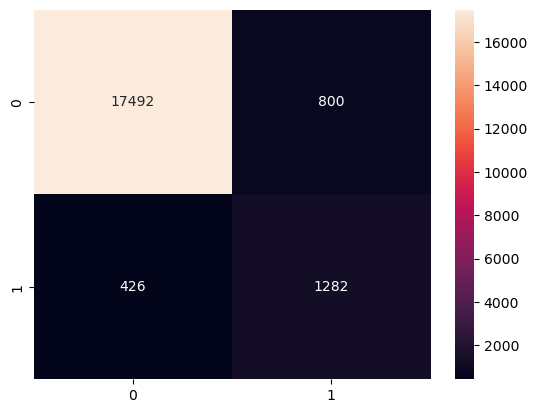

In [246]:
## Initialize Logistic regression
model = LogisticRegression(random_state =42, class_weight = {0:1 , 1:4})

#Train the model 
model.fit(X_train, y_train)
# Make predictions on the test set
predictions = model.predict(X_test)
report= classification_report(y_test, predictions, digits=5)
matrix = confusion_matrix(y_test, predictions)
print(report)

sns.heatmap(matrix , annot=True, fmt="g")



In [247]:
# Trying other  Machine learning Algorithims.

##Access if other libraries have better outcome on the data

classifiers = [[ XGBClassifier(),'XGB Classifier'],
               [RandomForestClassifier(),'Random Forest'],
               [KNeighborsClassifier(), 'K-nearest Neighbours'],
               [SGDClassifier(), 'SGD Classifier'],
               [SVC(), 'SVC'],
               [GaussianNB(), 'Naive Bayes'],
               [DecisionTreeClassifier(random_state =42), 'Decision tree'],
               [LogisticRegression(), 'Logistic regression']
              ]

<-- XGB Classifier -->
Classification Report:
               precision    recall  f1-score   support

           0     0.9725    0.9970    0.9846     18292
           1     0.9567    0.6985    0.8074      1708

    accuracy                         0.9716     20000
   macro avg     0.9646    0.8478    0.8960     20000
weighted avg     0.9712    0.9716    0.9695     20000



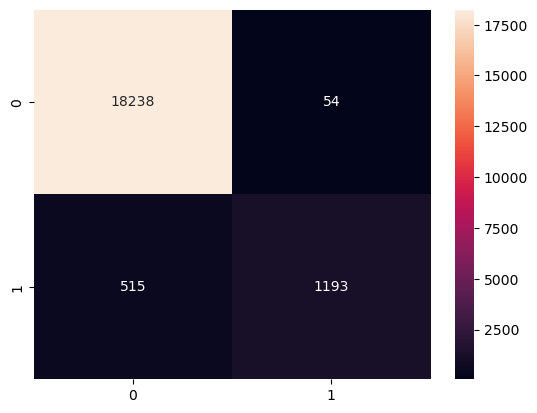

<-- Random Forest -->
Classification Report:
               precision    recall  f1-score   support

           0     0.9716    0.9959    0.9836     18292
           1     0.9400    0.6879    0.7945      1708

    accuracy                         0.9696     20000
   macro avg     0.9558    0.8419    0.8890     20000
weighted avg     0.9689    0.9696    0.9674     20000



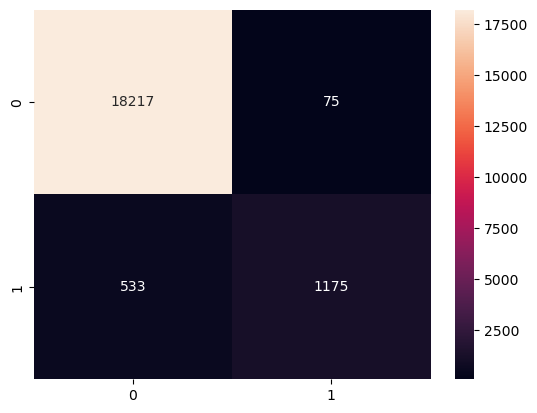

<-- K-nearest Neighbours -->
Classification Report:
               precision    recall  f1-score   support

           0     0.9570    0.9943    0.9753     18292
           1     0.8955    0.5217    0.6593      1708

    accuracy                         0.9539     20000
   macro avg     0.9262    0.7580    0.8173     20000
weighted avg     0.9518    0.9539    0.9483     20000



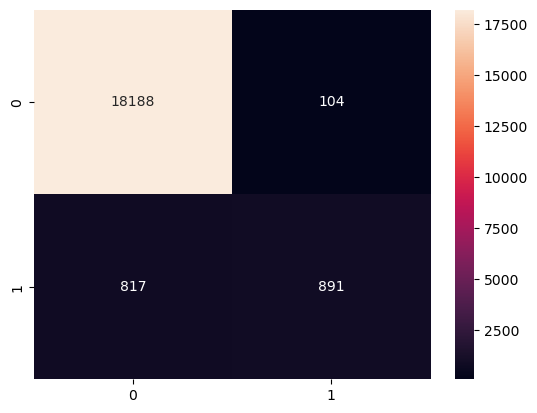

<-- SGD Classifier -->
Classification Report:
               precision    recall  f1-score   support

           0     0.9637    0.9915    0.9774     18292
           1     0.8686    0.6001    0.7098      1708

    accuracy                         0.9581     20000
   macro avg     0.9162    0.7958    0.8436     20000
weighted avg     0.9556    0.9581    0.9546     20000



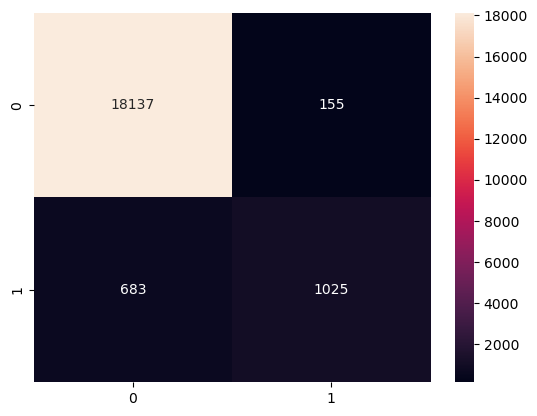

<-- SVC -->
Classification Report:
               precision    recall  f1-score   support

           0     0.9456    1.0000    0.9720     18292
           1     1.0000    0.3835    0.5544      1708

    accuracy                         0.9474     20000
   macro avg     0.9728    0.6917    0.7632     20000
weighted avg     0.9502    0.9474    0.9364     20000



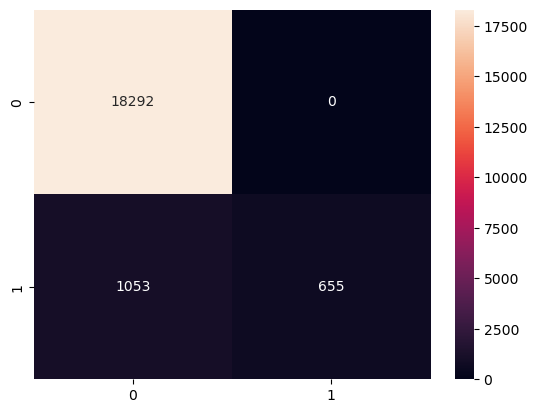

<-- Naive Bayes -->
Classification Report:
               precision    recall  f1-score   support

           0     0.9649    0.9309    0.9476     18292
           1     0.4626    0.6370    0.5360      1708

    accuracy                         0.9058     20000
   macro avg     0.7137    0.7840    0.7418     20000
weighted avg     0.9220    0.9058    0.9124     20000



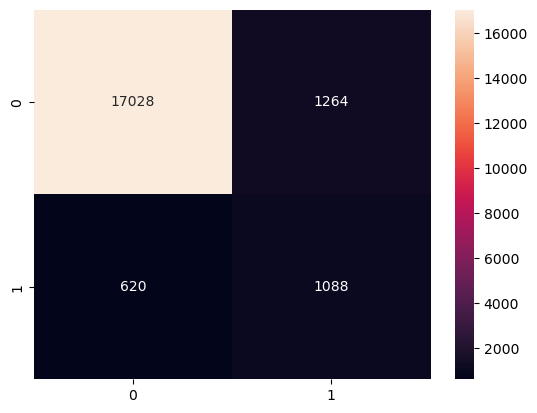

<-- Decision tree -->
Classification Report:
               precision    recall  f1-score   support

           0     0.9764    0.9734    0.9749     18292
           1     0.7245    0.7482    0.7362      1708

    accuracy                         0.9542     20000
   macro avg     0.8505    0.8608    0.8555     20000
weighted avg     0.9549    0.9542    0.9545     20000



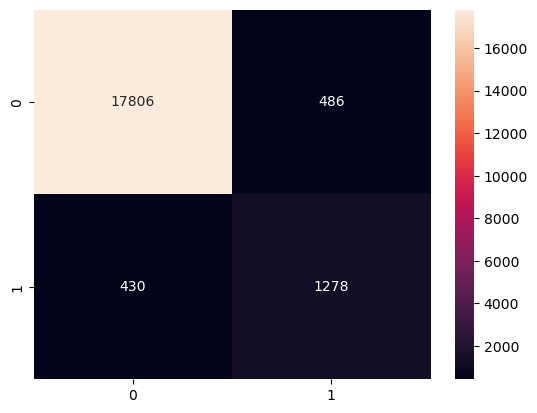

<-- Logistic regression -->
Classification Report:
               precision    recall  f1-score   support

           0     0.9621    0.9878    0.9748     18292
           1     0.8172    0.5837    0.6810      1708

    accuracy                         0.9533     20000
   macro avg     0.8897    0.7858    0.8279     20000
weighted avg     0.9498    0.9533    0.9497     20000



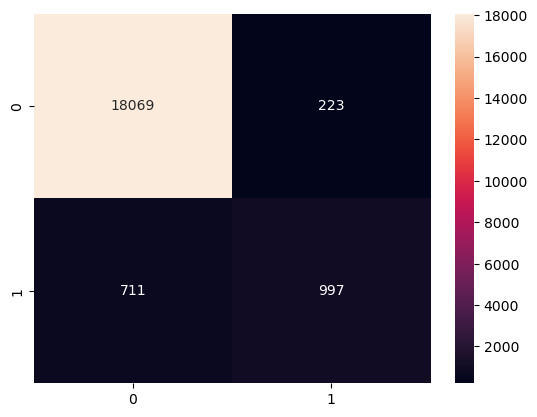

In [248]:
from sklearn.metrics import classification_report, confusion_matrix

for classifier in classifiers:
    model_name = classifier[1]
    model = classifier[0]
    print(f"<-- {model_name} -->")
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    report = classification_report(y_test, predictions, digits=4)
    matrix = confusion_matrix(y_test, predictions)
    print("Classification Report:\n", report)
    sns.heatmap(matrix, annot=True, fmt='g')
    plt.show()




## Summary


The classification reports provided compares the performance of different machine learning models for a binary classification task. The models are: XGBoost (XGB Classifier), Random Forest, K-Nearest Neighbors (KNN), and Stochastic Gradient Descent (SGD)

Objective: This report evaluates the performance of five machine learning models for a binary classification task, focusing on key metrics like precision, recall, F1-score, and accuracy. The results help identify the most suitable model for deployment based on overall performance:




Logistic Regression
Summary: Logistic Regression has lower precision but higher recall for class 1 compared to other models. It is better at identifying positive cases but generates more false positives. Its accuracy and F1-score are lower than XGBoost and Random Forest but comparable to SGD.


XGBoost Classifier
Summary: Best overall performance, combining high precision, recall, and accuracy. Recommended for deployment.

Random Forest Classifier
Summary: Very close to XGBoost in performance, a strong alternative.


K-Nearest Neighbors (KNN)
Summary: Lower recall for positive cases, less suitable for identifying minority class.


SGD Classifier
Summary: Lowest precision and accuracy, not recommended for this task.


Recommendation:
Based on the analysis, XGBoost is the top-performing model, recommended for deployment due to its strong balance between precision and recall. Random Forest is a close second and could also be considered if an alternative model is required. It is recommended for deployment, particularly if high accuracy and reliable positive case identification are critical for business success. 

## Scale the data Model



In [253]:
from sklearn.preprocessing import StandardScaler

# Scale our training data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

              precision    recall  f1-score   support

           0    0.97796   0.95583   0.96677     18292
           1    0.61923   0.76932   0.68616      1708

    accuracy                        0.93990     20000
   macro avg    0.79859   0.86257   0.82646     20000
weighted avg    0.94733   0.93990   0.94280     20000



<Axes: >

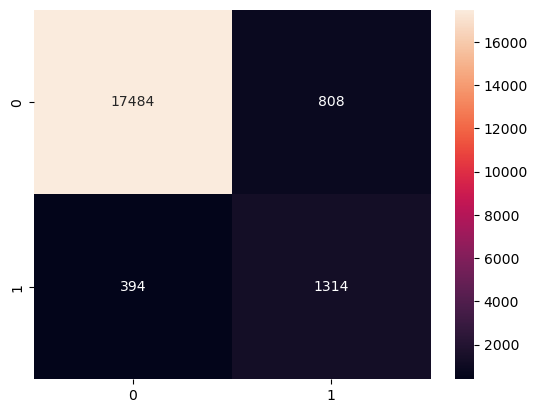

In [254]:
## Initialize Logistic regression
model = LogisticRegression(random_state =42, class_weight = {0:1 , 1:4})

#Train the model 
model.fit(X_train_scaled, y_train)
# Make predictions on the test set
predictions = model.predict(X_test_scaled)
report= classification_report(y_test, predictions, digits=5)
matrix = confusion_matrix(y_test, predictions)
print(report)

sns.heatmap(matrix , annot=True, fmt=".6g")

We can see the improvements in the class 1  predictions and slightly in the overall accuracy, precision, recall

In [258]:
# Trying other  Machine learning Algorithims.

##Access if other libraries have better outcome on the data

classifiers = [[ XGBClassifier(),'XGB Classifier'],
               [RandomForestClassifier(),'Random Forest'],
               [KNeighborsClassifier(), 'K-nearest Neighbours'],
               [SGDClassifier(), 'SGD Classifier'],
               [SVC(), 'SVC'],
               [GaussianNB(), 'Naive Bayes'],
               [DecisionTreeClassifier(random_state =42), 'Decision tree'],
               [LogisticRegression(), 'Logistic regression']
              ]

<-- XGB Classifier -->
Classification Report:
               precision    recall  f1-score   support

           0     0.9725    0.9970    0.9846     18292
           1     0.9567    0.6985    0.8074      1708

    accuracy                         0.9716     20000
   macro avg     0.9646    0.8478    0.8960     20000
weighted avg     0.9712    0.9716    0.9695     20000



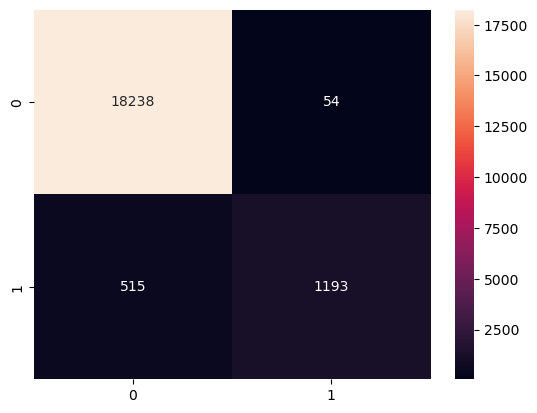

<-- Random Forest -->
Classification Report:
               precision    recall  f1-score   support

           0     0.9717    0.9957    0.9836     18292
           1     0.9372    0.6897    0.7946      1708

    accuracy                         0.9696     20000
   macro avg     0.9544    0.8427    0.8891     20000
weighted avg     0.9688    0.9696    0.9674     20000



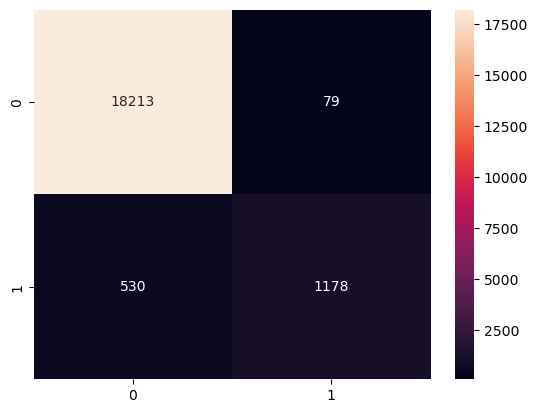

<-- K-nearest Neighbours -->
Classification Report:
               precision    recall  f1-score   support

           0     0.9650    0.9930    0.9788     18292
           1     0.8912    0.6142    0.7272      1708

    accuracy                         0.9607     20000
   macro avg     0.9281    0.8036    0.8530     20000
weighted avg     0.9587    0.9607    0.9573     20000



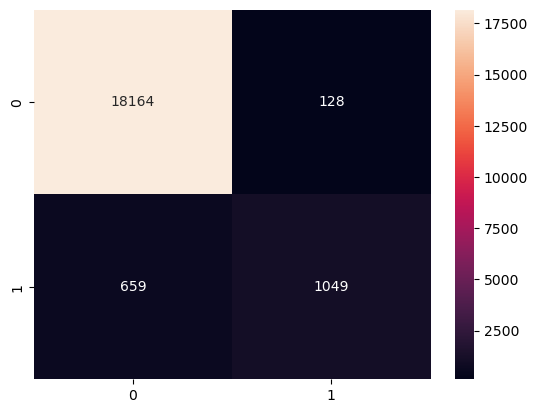

<-- SGD Classifier -->
Classification Report:
               precision    recall  f1-score   support

           0     0.9608    0.9943    0.9772     18292
           1     0.9027    0.5650    0.6950      1708

    accuracy                         0.9577     20000
   macro avg     0.9317    0.7797    0.8361     20000
weighted avg     0.9558    0.9577    0.9531     20000



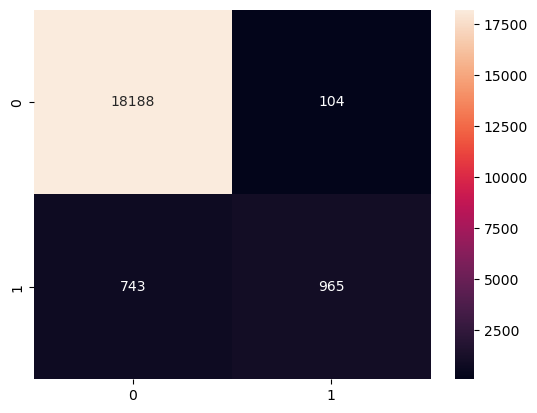

<-- SVC -->
Classification Report:
               precision    recall  f1-score   support

           0     0.9613    0.9990    0.9798     18292
           1     0.9808    0.5697    0.7207      1708

    accuracy                         0.9623     20000
   macro avg     0.9711    0.7843    0.8503     20000
weighted avg     0.9630    0.9623    0.9577     20000



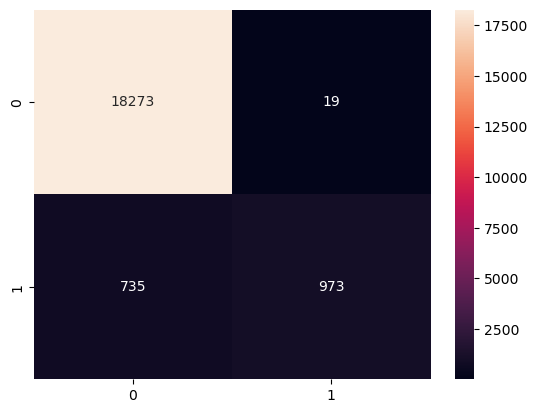

<-- Naive Bayes -->
Classification Report:
               precision    recall  f1-score   support

           0     0.9649    0.9309    0.9476     18292
           1     0.4626    0.6370    0.5360      1708

    accuracy                         0.9058     20000
   macro avg     0.7137    0.7840    0.7418     20000
weighted avg     0.9220    0.9058    0.9124     20000



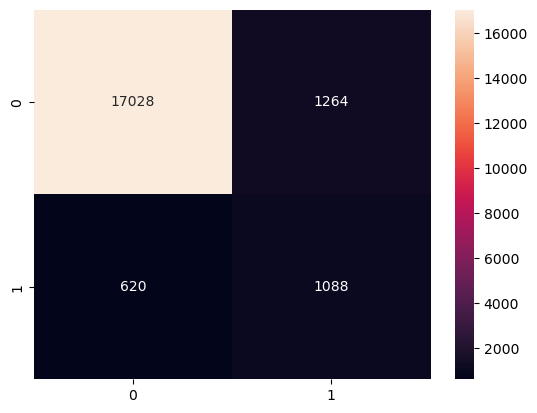

<-- Decision tree -->
Classification Report:
               precision    recall  f1-score   support

           0     0.9764    0.9732    0.9748     18292
           1     0.7229    0.7482    0.7353      1708

    accuracy                         0.9540     20000
   macro avg     0.8496    0.8607    0.8551     20000
weighted avg     0.9548    0.9540    0.9544     20000



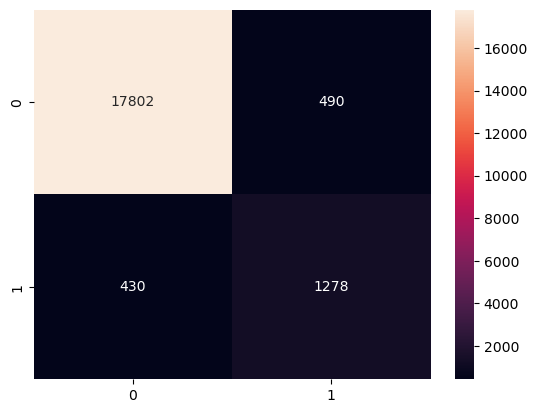

<-- Logistic regression -->
Classification Report:
               precision    recall  f1-score   support

           0     0.9649    0.9909    0.9777     18292
           1     0.8634    0.6142    0.7178      1708

    accuracy                         0.9587     20000
   macro avg     0.9141    0.8025    0.8478     20000
weighted avg     0.9562    0.9587    0.9555     20000



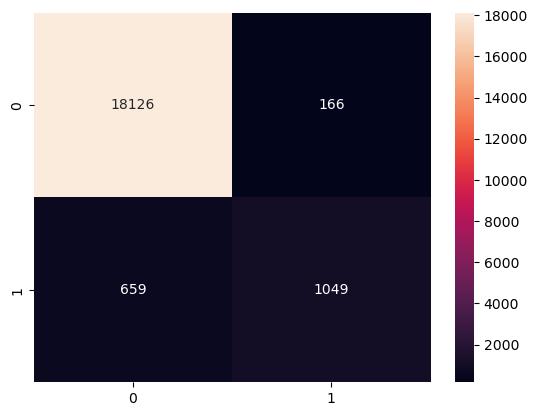

In [259]:
from sklearn.metrics import classification_report, confusion_matrix

for classifier in classifiers:
    model_name = classifier[1]
    model = classifier[0]
    print(f"<-- {model_name} -->")
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    report = classification_report(y_test, predictions, digits=4)
    matrix = confusion_matrix(y_test, predictions)
    print("Classification Report:\n", report)
    sns.heatmap(matrix, annot=True, fmt='g')
    plt.show()

## Features Importance
#### Slim down the model size by selecting the most important features 

In [261]:
classifiers[0][0]

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [262]:
importances = classifiers[0][0].feature_importances_
importances

array([0.01567817, 0.0334753 , 0.04016354, 0.03850586, 0.01513163,
       0.01898794, 0.5621362 , 0.2759214 ], dtype=float32)

In [263]:
len(importances) == len(features.columns)

True

In [264]:
imp_feature_names = features.columns
feature_importance_df = pd.DataFrame({'Feature': imp_feature_names, 'Importance': importances})
feature_importance_df

,Feature,Importance
0,gender,0.015678
1,age,0.033475
2,hypertension,0.040164
3,heart_disease,0.038506
4,smoking_history,0.015132
5,bmi,0.018988
6,HbA1c_level,0.562136
7,blood_glucose_level,0.275921


In [266]:
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
feature_importance_df

,Feature,Importance
6,HbA1c_level,0.562136
7,blood_glucose_level,0.275921
2,hypertension,0.040164
3,heart_disease,0.038506
1,age,0.033475
5,bmi,0.018988
0,gender,0.015678
4,smoking_history,0.015132


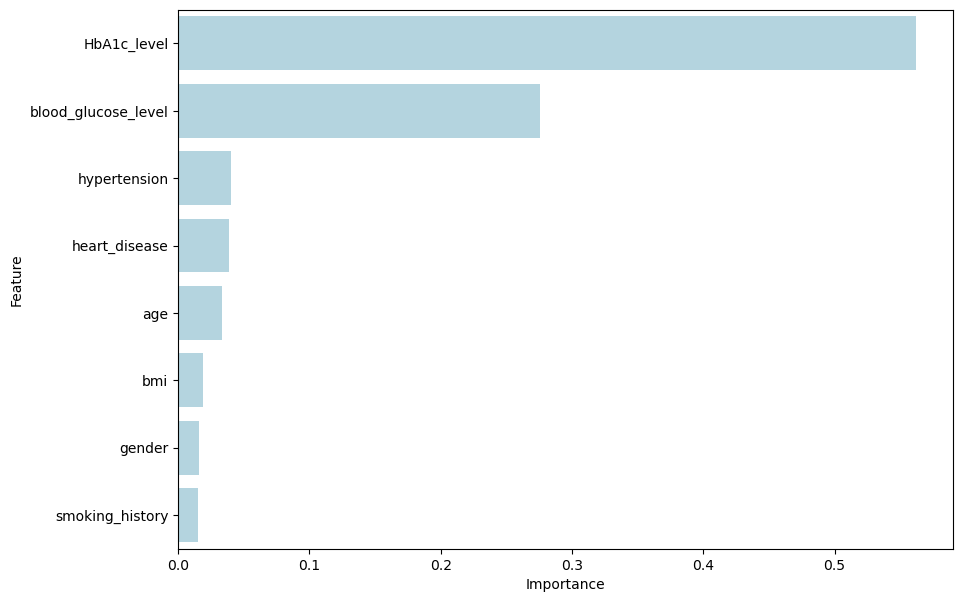

In [276]:
plt.figure(figsize=(10, 7))

sns.barplot(x='Importance', y='Feature', data=feature_importance_df, color='lightblue');

As observed , HbA1c_level , blood glucose level and hypertension are the most important features in our dataset in predicticting diabetes .

Smoking history has the least effect or its the least important feature  in predicting diabetes .

In [280]:
top5_features = feature_importance_df[:5]
top5_features

,Feature,Importance
6,HbA1c_level,0.562136
7,blood_glucose_level,0.275921
2,hypertension,0.040164
3,heart_disease,0.038506
1,age,0.033475


In [282]:
X_train[top5_features['Feature'].values]

,HbA1c_level,blood_glucose_level,hypertension,heart_disease,age
75220,3.5,80,0,0,73.0
48955,5.7,145,0,0,80.0
44966,4.0,158,0,0,38.0
13568,5.0,100,0,0,26.0
92727,4.5,85,1,0,61.0
...,...,...,...,...,...
6265,5.7,80,0,0,49.0
54886,5.0,159,0,0,15.0
76820,5.8,85,0,0,42.0
860,6.2,158,0,0,37.0


In [284]:
Xtrain_top_five = X_train[top5_features['Feature'].values]
Xtest_top_five = X_test[top5_features['Feature'].values]

<-- XGB Classifier -->
Classification Report:
               precision    recall  f1-score   support

           0     0.9711    0.9987    0.9847     18292
           1     0.9806    0.6815    0.8041      1708

    accuracy                         0.9717     20000
   macro avg     0.9759    0.8401    0.8944     20000
weighted avg     0.9719    0.9717    0.9693     20000



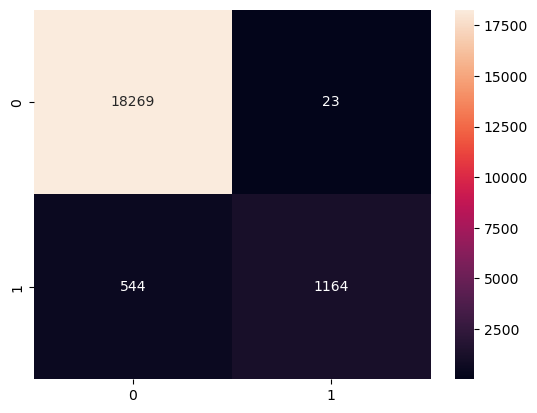

<-- Random Forest -->
Classification Report:
               precision    recall  f1-score   support

           0     0.9723    0.9936    0.9829     18292
           1     0.9106    0.6973    0.7898      1708

    accuracy                         0.9683     20000
   macro avg     0.9414    0.8455    0.8863     20000
weighted avg     0.9671    0.9683    0.9664     20000



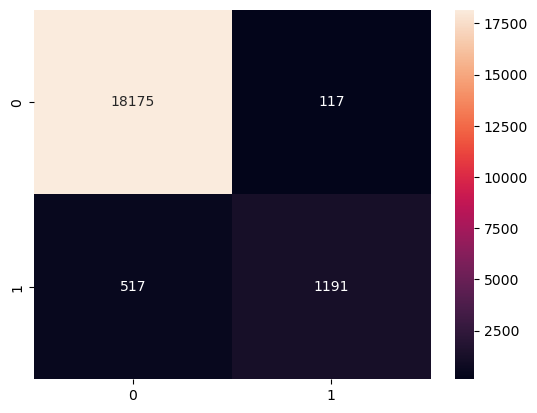

<-- K-nearest Neighbours -->
Classification Report:
               precision    recall  f1-score   support

           0     0.9629    0.9948    0.9786     18292
           1     0.9138    0.5896    0.7167      1708

    accuracy                         0.9602     20000
   macro avg     0.9383    0.7922    0.8477     20000
weighted avg     0.9587    0.9602    0.9562     20000



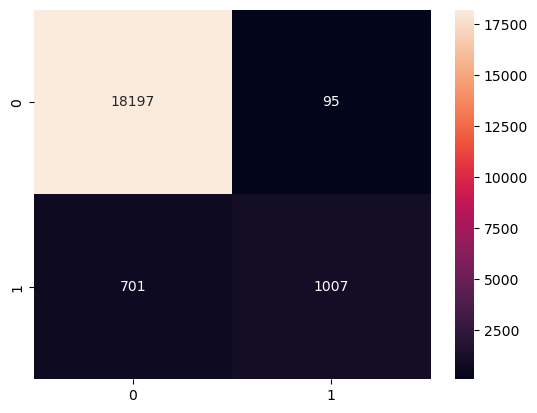

<-- SGD Classifier -->
Classification Report:
               precision    recall  f1-score   support

           0     0.9680    0.9826    0.9752     18292
           1     0.7774    0.6522    0.7093      1708

    accuracy                         0.9544     20000
   macro avg     0.8727    0.8174    0.8423     20000
weighted avg     0.9517    0.9544    0.9525     20000



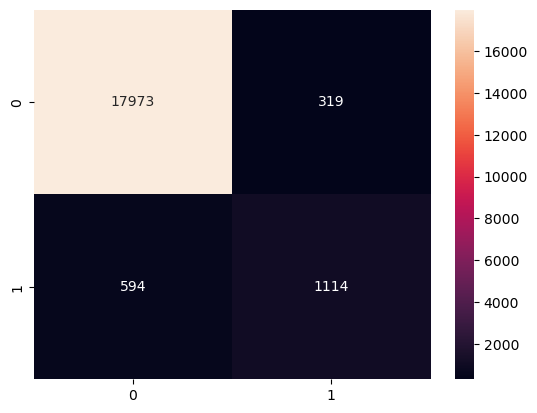

<-- SVC -->
Classification Report:
               precision    recall  f1-score   support

           0     0.9453    1.0000    0.9719     18292
           1     1.0000    0.3806    0.5513      1708

    accuracy                         0.9471     20000
   macro avg     0.9727    0.6903    0.7616     20000
weighted avg     0.9500    0.9471    0.9360     20000



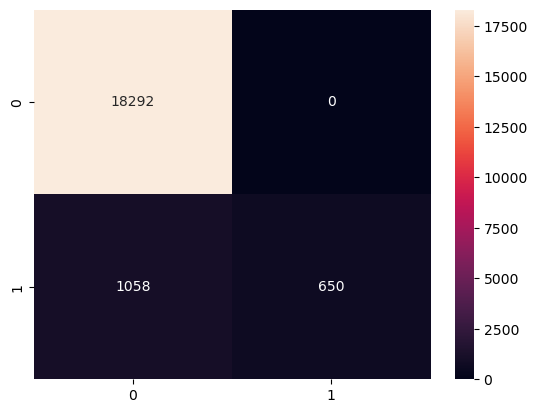

<-- Naive Bayes -->
Classification Report:
               precision    recall  f1-score   support

           0     0.9631    0.9330    0.9479     18292
           1     0.4627    0.6177    0.5291      1708

    accuracy                         0.9061     20000
   macro avg     0.7129    0.7754    0.7385     20000
weighted avg     0.9204    0.9061    0.9121     20000



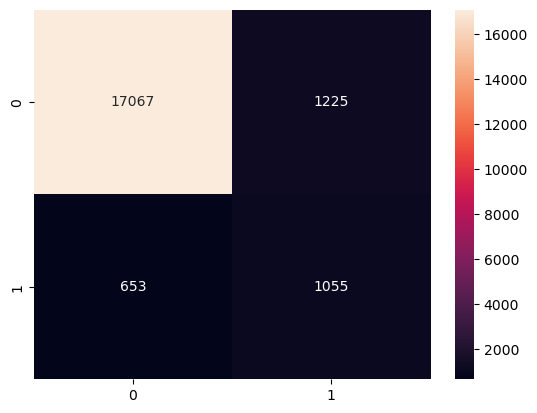

<-- Decision tree -->
Classification Report:
               precision    recall  f1-score   support

           0     0.9725    0.9924    0.9824     18292
           1     0.8958    0.6996    0.7857      1708

    accuracy                         0.9674     20000
   macro avg     0.9342    0.8460    0.8840     20000
weighted avg     0.9660    0.9674    0.9656     20000



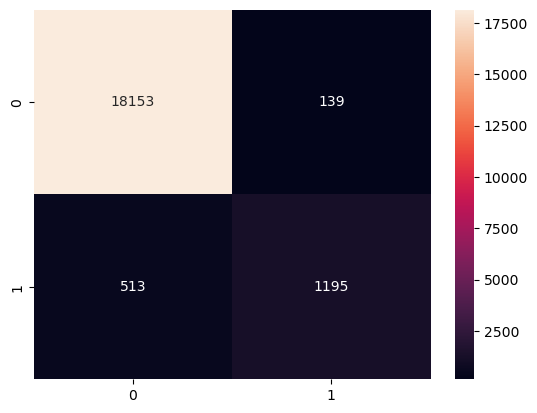

<-- Logistic regression -->
Classification Report:
               precision    recall  f1-score   support

           0     0.9627    0.9909    0.9766     18292
           1     0.8584    0.5890    0.6986      1708

    accuracy                         0.9566     20000
   macro avg     0.9105    0.7900    0.8376     20000
weighted avg     0.9538    0.9566    0.9529     20000



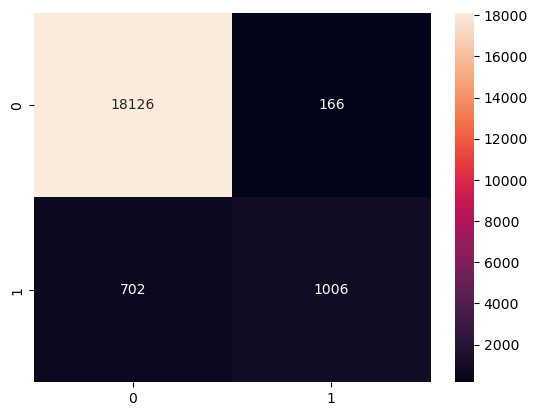

In [288]:
for classifier in classifiers:
    model_name = classifier[1]
    model = classifier[0]
    print(f"<-- {model_name} -->")
    model.fit(Xtrain_top_five, y_train)
    predictions = model.predict(Xtest_top_five)
    report = classification_report(y_test, predictions, digits=4)
    matrix = confusion_matrix(y_test, predictions)
    print("Classification Report:\n", report)
    sns.heatmap(matrix, annot=True, fmt='g')
    plt.show()

A huge improvemnt has been noticed on all classifies with use of feature importance .